In [13]:
import os, pandas as pd, numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os, sys
import time

In [14]:
print(f"Python version: {sys.version}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
NumPy version:  2.2.6
Pandas version: 2.3.3


In [15]:
import pltfont # mac 전용 한글 깨짐 라이브러리

# 데이터 불러오기

In [16]:
df_raw =pd.read_csv("/Users/jun/GitStudy/human_A/data/smartfarm_nutrient_pump_rawdata_3months_refined_smoother_m2_m3.csv")

# 데이터 상태 확인

In [17]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129591 entries, 0 to 129590
Data columns (total 45 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   timestamp                     129591 non-null  object 
 1   light_ppfd_umol_m2_s          129591 non-null  float64
 2   air_temp_c                    129591 non-null  float64
 3   relative_humidity_pct         129591 non-null  float64
 4   co2_ppm                       129591 non-null  float64
 5   raw_tank_level_pct            129591 non-null  float64
 6   raw_water_temp_c              129591 non-null  float64
 7   pump_rpm                      129591 non-null  float64
 8   flow_rate_l_min               129591 non-null  float64
 9   suction_pressure_kpa          129591 non-null  float64
 10  discharge_pressure_kpa        129591 non-null  float64
 11  motor_current_a               129591 non-null  float64
 12  motor_power_kw                129591 non-nul

<bound method NDFrame.keys of        light_ppfd_umol_m2_s     air_temp_c  relative_humidity_pct  \
count         129591.000000  129591.000000          129591.000000   
mean             276.655787      20.335191              73.523521   
std              323.124863       2.986643               6.025484   
min                0.000000      16.258000              56.067000   
25%                8.874000      18.224000              70.750000   
50%               31.011000      19.283000              75.820000   
75%              601.505000      21.685500              77.752000   
max              877.452000      28.730000              81.764000   

             co2_ppm  raw_tank_level_pct  raw_water_temp_c       pump_rpm  \
count  129591.000000       129591.000000     129591.000000  129591.000000   
mean      505.694034           72.900442         18.002829    1036.443440   
std        81.801978            5.508719          1.145323     664.955882   
min       408.476000           62.231000

#### 데이터 형 변환

In [19]:
# 타임스탬프 데이터타입으로 변환
df_raw["timestamp"] = pd.to_datetime(df_raw['timestamp'])

In [20]:
# 'id' 컬럼을 인덱스(PK 역할)로 설정
df_raw = df_raw.set_index('timestamp')

# 결측치 확인 

In [21]:
df_raw[df_raw.isnull()].count()

light_ppfd_umol_m2_s            0
air_temp_c                      0
relative_humidity_pct           0
co2_ppm                         0
raw_tank_level_pct              0
raw_water_temp_c                0
pump_rpm                        0
flow_rate_l_min                 0
suction_pressure_kpa            0
discharge_pressure_kpa          0
motor_current_a                 0
motor_power_kw                  0
bearing_vibration_rms_mm_s      0
motor_temperature_c             0
bearing_temperature_c           0
filter_pressure_in_kpa          0
filter_pressure_out_kpa         0
turbidity_ntu                   0
mix_target_ec_ds_m              0
mix_ec_ds_m                     0
mix_target_ph                   0
mix_ph                          0
mix_temp_c                      0
mix_flow_l_min                  0
dosing_acid_ml_min              0
drain_ec_ds_m                   0
tank_a_level_pct                0
tank_b_level_pct                0
acid_tank_level_pct             0
zone1_flow_l_m

In [22]:
df_raw[df_raw.isnull()].count().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

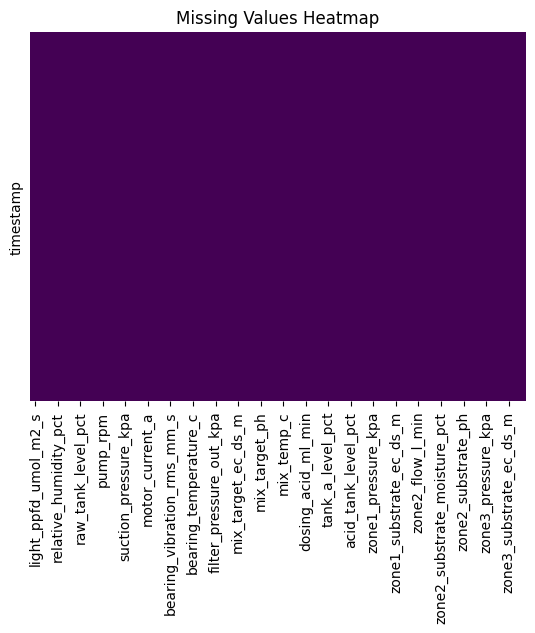

In [23]:
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

# 데이터 상관관계 확인

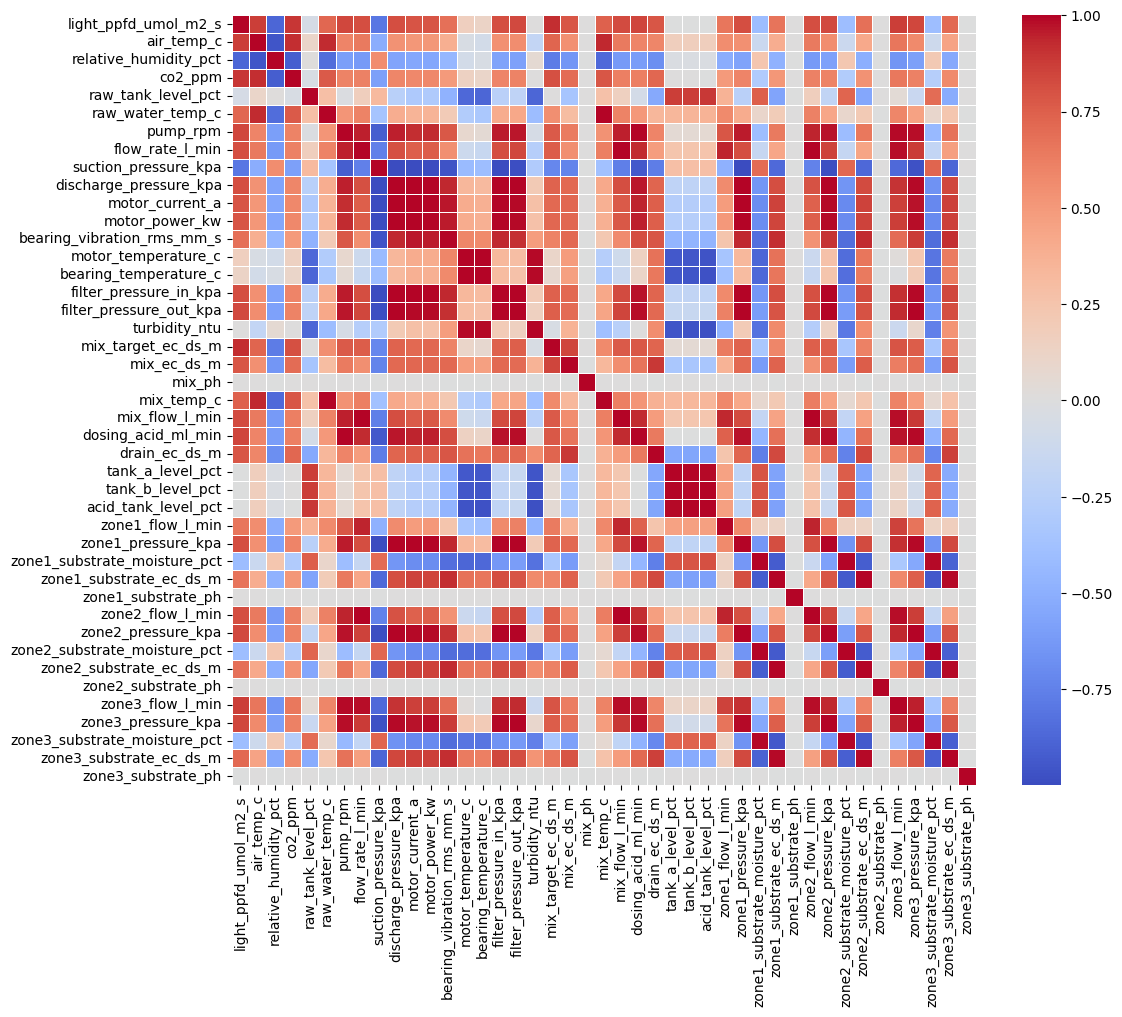

In [24]:
# 상관계수 계산
corr = df_raw.corr(numeric_only=True)

# 특정 기준(예: 상관계수 0.5) 이상의 관계가 하나라도 있는 컬럼만 추출
threshold = 0.5
high_corr_cols = corr.columns[(corr.abs() > threshold).any()]
filtered_corr = corr.loc[high_corr_cols, high_corr_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.show()

In [25]:
# 2. 전체 상관계수 계산 (숫자형 + 수치화된 범주형)
corr_matrix = df_raw.corr(numeric_only=True).abs()

# 3. 상삼각 행렬만 추출
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [26]:
threshold = 0.7
high_corr_pairs = np.where(upper > threshold)

# 쌍(Pair) 리스트 생성
pairs = [(upper.index[i], upper.columns[j], upper.iloc[i, j]) 
        for i, j in zip(*high_corr_pairs)]

# 그룹화 (Dictionary 활용)
groups = {}
for p1, p2, val in pairs:
    if p1 not in groups: groups[p1] = []
    groups[p1].append(f"{p2}({val:.2f})")

print(f"--- [상관계수 {threshold} 이상] 연관 변수 그룹 ---")
if not groups:
    print("기준치를 넘는 고상관 변수가 없습니다.")
else:
    for key, values in groups.items():
        print(f"[{key}] 변수와 중복 위험: {', '.join(values)}\n")

--- [상관계수 0.7 이상] 연관 변수 그룹 ---
[light_ppfd_umol_m2_s] 변수와 중복 위험: air_temp_c(0.87), relative_humidity_pct(0.88), co2_ppm(0.90), raw_water_temp_c(0.72), pump_rpm(0.84), flow_rate_l_min(0.82), suction_pressure_kpa(0.80), discharge_pressure_kpa(0.81), motor_current_a(0.79), motor_power_kw(0.80), filter_pressure_in_kpa(0.82), filter_pressure_out_kpa(0.83), mix_target_ec_ds_m(0.91), mix_ec_ds_m(0.79), mix_temp_c(0.75), mix_flow_l_min(0.83), dosing_acid_ml_min(0.85), drain_ec_ds_m(0.78), zone1_pressure_kpa(0.82), zone2_flow_l_min(0.82), zone2_pressure_kpa(0.83), zone3_flow_l_min(0.87), zone3_pressure_kpa(0.84), zone3_substrate_ec_ds_m(0.72)

[air_temp_c] 변수와 중복 위험: relative_humidity_pct(0.95), co2_ppm(0.92), raw_water_temp_c(0.92), mix_target_ec_ds_m(0.73), mix_temp_c(0.93)

[relative_humidity_pct] 변수와 중복 위험: co2_ppm(0.92), raw_water_temp_c(0.85), mix_target_ec_ds_m(0.78), mix_temp_c(0.87)

[co2_ppm] 변수와 중복 위험: raw_water_temp_c(0.77), mix_target_ec_ds_m(0.81), mix_ec_ds_m(0.70), mix_temp_c(0.

In [27]:
df_raw.to_timestamp

<bound method DataFrame.to_timestamp of                      light_ppfd_umol_m2_s  air_temp_c  relative_humidity_pct  \
timestamp                                                                      
2026-03-01 00:00:00                 2.252      17.538                 78.516   
2026-03-01 00:01:00                 2.134      17.539                 78.614   
2026-03-01 00:02:00                 2.010      17.541                 78.718   
2026-03-01 00:03:00                 1.881      17.543                 78.826   
2026-03-01 00:04:00                 1.643      17.546                 79.024   
...                                   ...         ...                    ...   
2026-05-29 23:46:00                11.140      17.809                 78.638   
2026-05-29 23:47:00                11.387      17.797                 78.679   
2026-05-29 23:48:00                11.521      17.791                 78.701   
2026-05-29 23:49:00                11.651      17.785                 78.722   


In [28]:
compare_groups = {
    # 1. 구역별 양액 공급 균일도 체크
    "Flow Rate Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_flow_l_min", "zone2_flow_l_min", "zone3_flow_l_min", "mix_flow_l_min"
    ],
    # 2. 구역별 관수 압력 편차 (노즐 막힘 확인용)
    "Pressure Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_pressure_kpa", "zone2_pressure_kpa", "zone3_pressure_kpa"
    ],
    # 3. 양액 산도 변화 (원천-혼합-배지)
    "pH Comparison (Mix vs Substrate)": [
        "mix_target_ph", "mix_ph", "zone1_substrate_ph", "zone2_substrate_ph", "zone3_substrate_ph"
    ],
    # 4. 양액 농도 변화 (혼합-배지-배액)
    "EC Comparison (Mix vs Substrate vs Drain)": [
        "mix_target_ec_ds_m", "mix_ec_ds_m", "drain_ec_ds_m", 
        "zone1_substrate_ec_ds_m", "zone2_substrate_ec_ds_m", "zone3_substrate_ec_ds_m"
    ],
    # 5. 온도 상관관계 (기온-양액-모터)
    "Temperature Comparison": [
        "air_temp_c", "mix_temp_c", "raw_water_temp_c", "motor_temperature_c", "bearing_temperature_c"
    ],
    # 6. 저장탱크 잔량 (공급 원료 모니터링)
    "Tank Levels": [
        "raw_tank_level_pct", "tank_a_level_pct", "tank_b_level_pct", "acid_tank_level_pct"
    ],
    # 7. 펌프 및 필터 압력 계통 (예지보전 핵심)
    "System Pressure": [
        "filter_pressure_in_kpa", "filter_pressure_out_kpa", 
        "suction_pressure_kpa", "discharge_pressure_kpa"
    ],
    # 8. 모터 부하 및 상태 모니터링
    "Motor & Pump Health": [
        "motor_current_a", "motor_power_kw", "bearing_vibration_rms_mm_s"
    ],

    # 9. 생육 환경 및 리스크 지표
    "Environment & Hidden Risks": [
        "light_ppfd_umol_m2_s", "co2_ppm",
        "hidden_tip_clog_level", "hidden_blocked_tip_ratio", "hidden_risk_stage"
    ],

    # 10. motor 
    "Pump RPM" : [
        "pump_rpm"
    ],

    # 11. humidity
    "humidity" : [
        "relative_humidity_pct"
    ]
}

In [29]:
df_raw.columns

Index(['light_ppfd_umol_m2_s', 'air_temp_c', 'relative_humidity_pct',
       'co2_ppm', 'raw_tank_level_pct', 'raw_water_temp_c', 'pump_rpm',
       'flow_rate_l_min', 'suction_pressure_kpa', 'discharge_pressure_kpa',
       'motor_current_a', 'motor_power_kw', 'bearing_vibration_rms_mm_s',
       'motor_temperature_c', 'bearing_temperature_c',
       'filter_pressure_in_kpa', 'filter_pressure_out_kpa', 'turbidity_ntu',
       'mix_target_ec_ds_m', 'mix_ec_ds_m', 'mix_target_ph', 'mix_ph',
       'mix_temp_c', 'mix_flow_l_min', 'dosing_acid_ml_min', 'drain_ec_ds_m',
       'tank_a_level_pct', 'tank_b_level_pct', 'acid_tank_level_pct',
       'zone1_flow_l_min', 'zone1_pressure_kpa',
       'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m',
       'zone1_substrate_ph', 'zone2_flow_l_min', 'zone2_pressure_kpa',
       'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m',
       'zone2_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa',
       'zone3_substrate_moisture_p

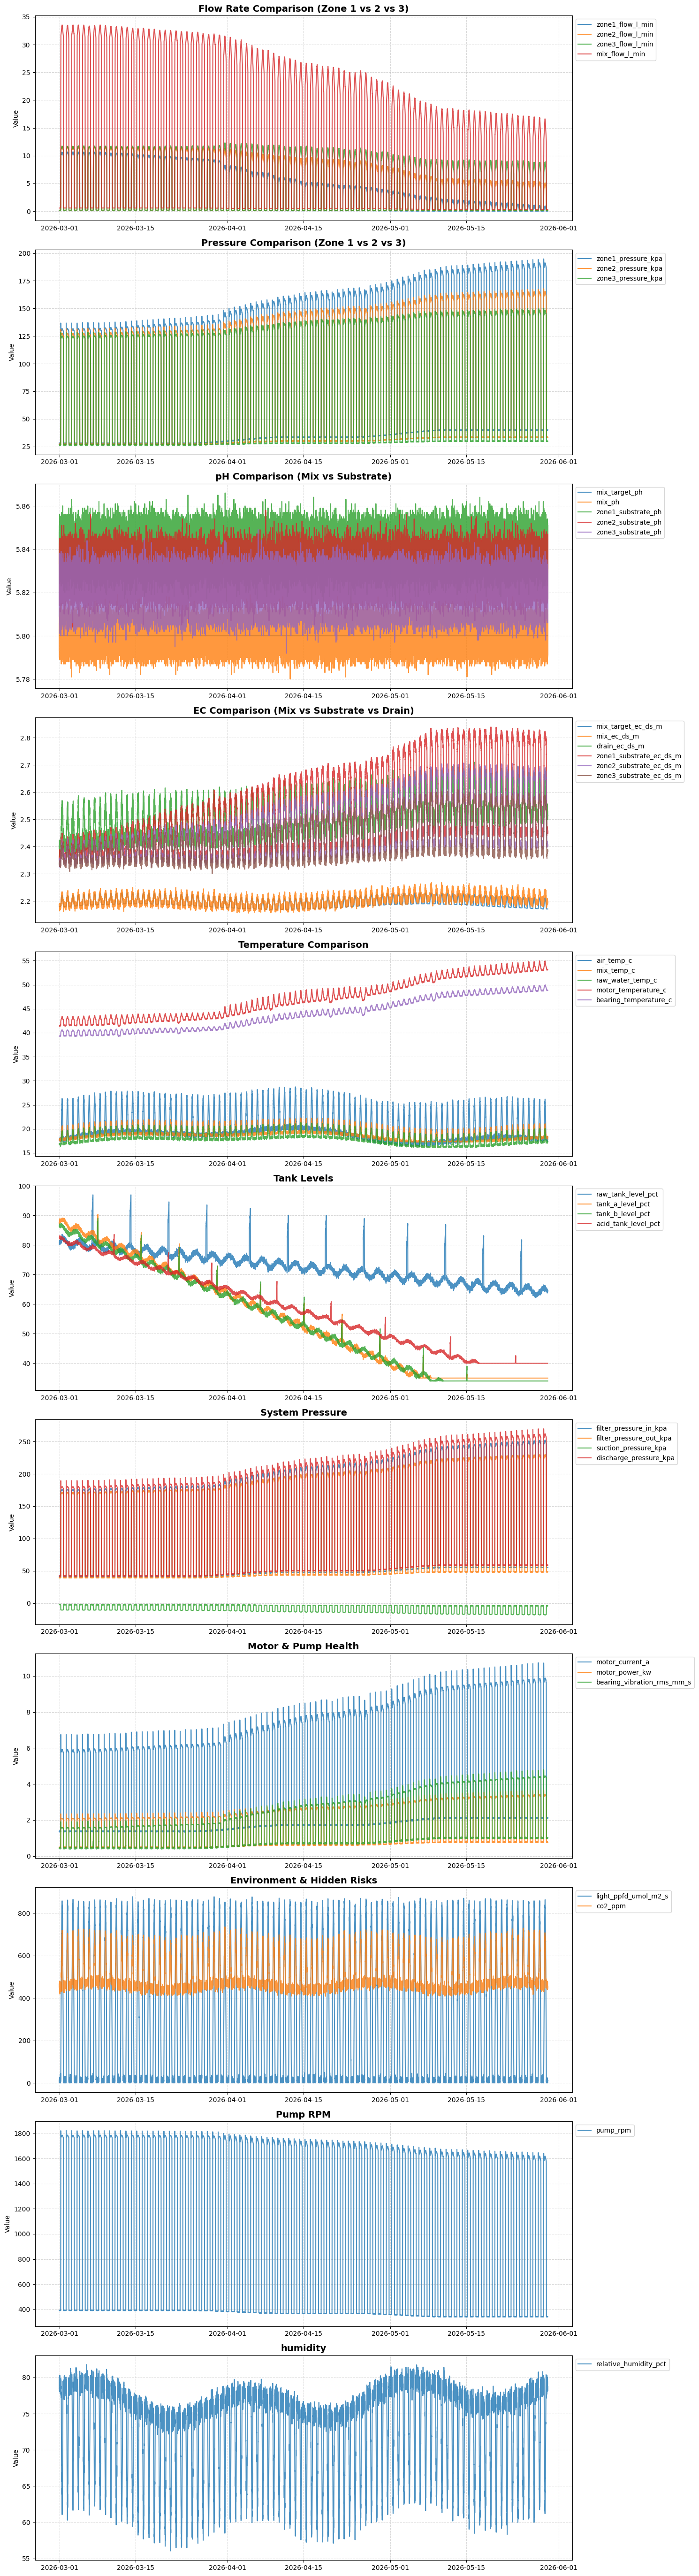

In [35]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
# 10분 간격, 60분, 24시간 이니까  = 6*24
plot_df = df_raw.iloc[:] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

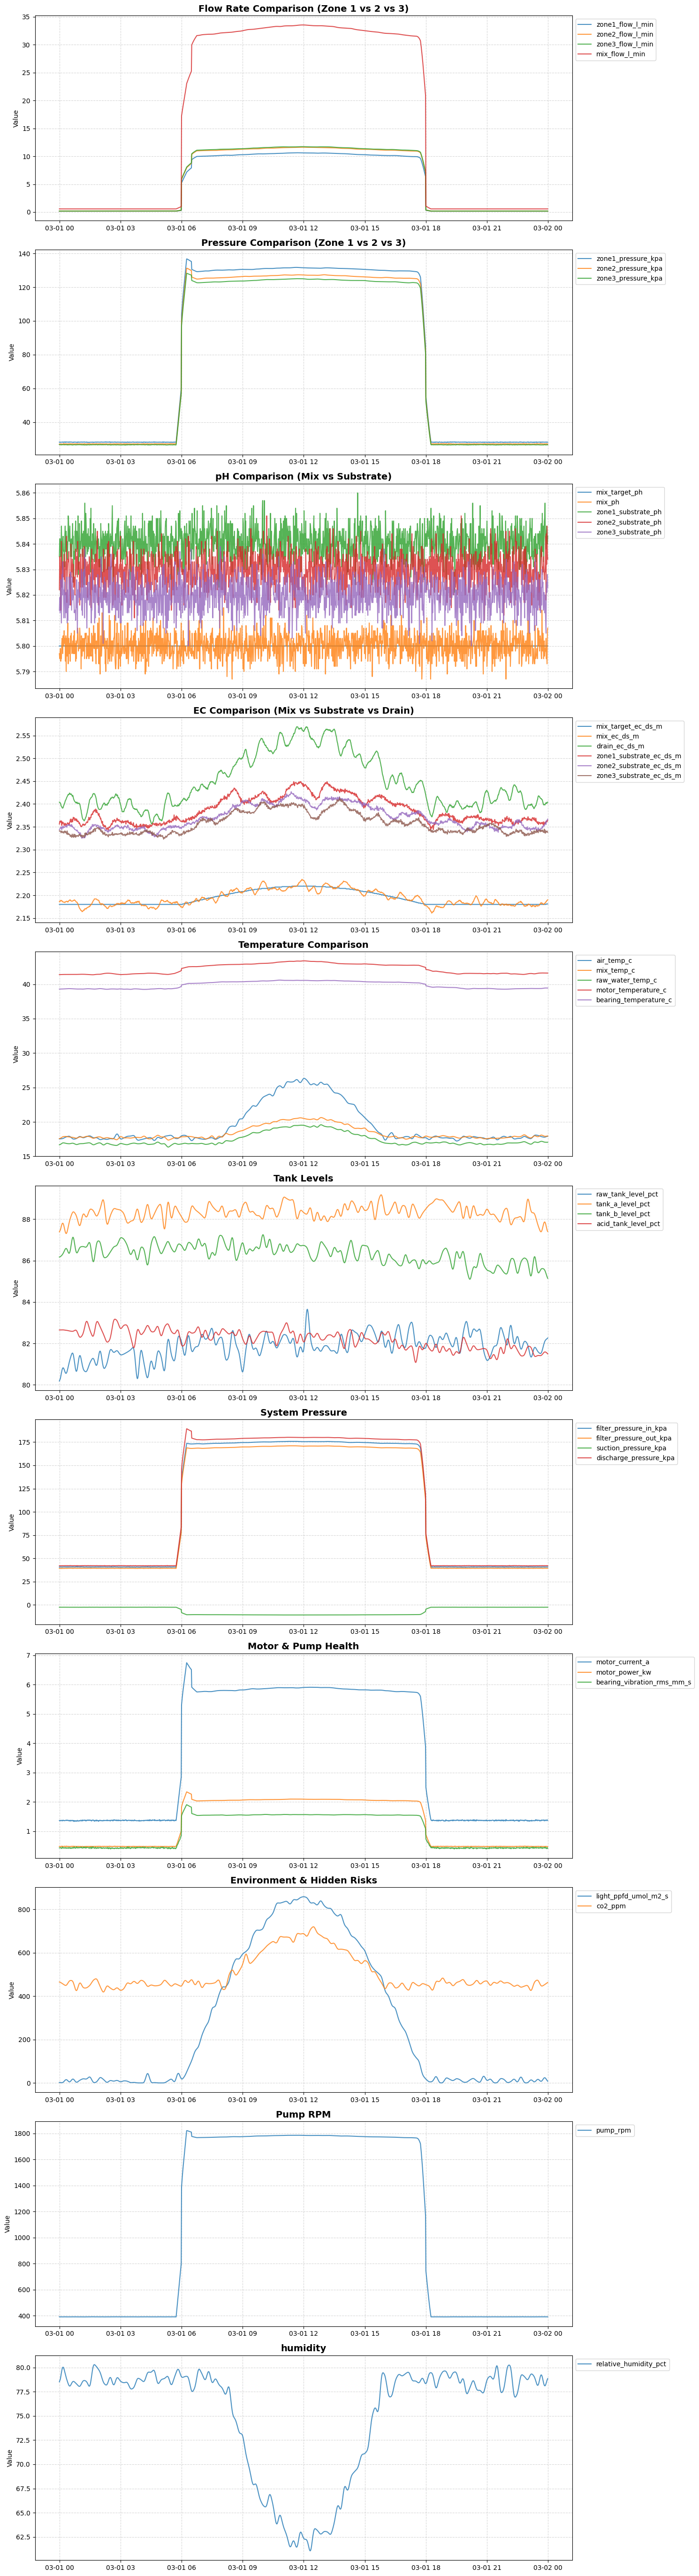

In [36]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


minute_per_day = 60*24

# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

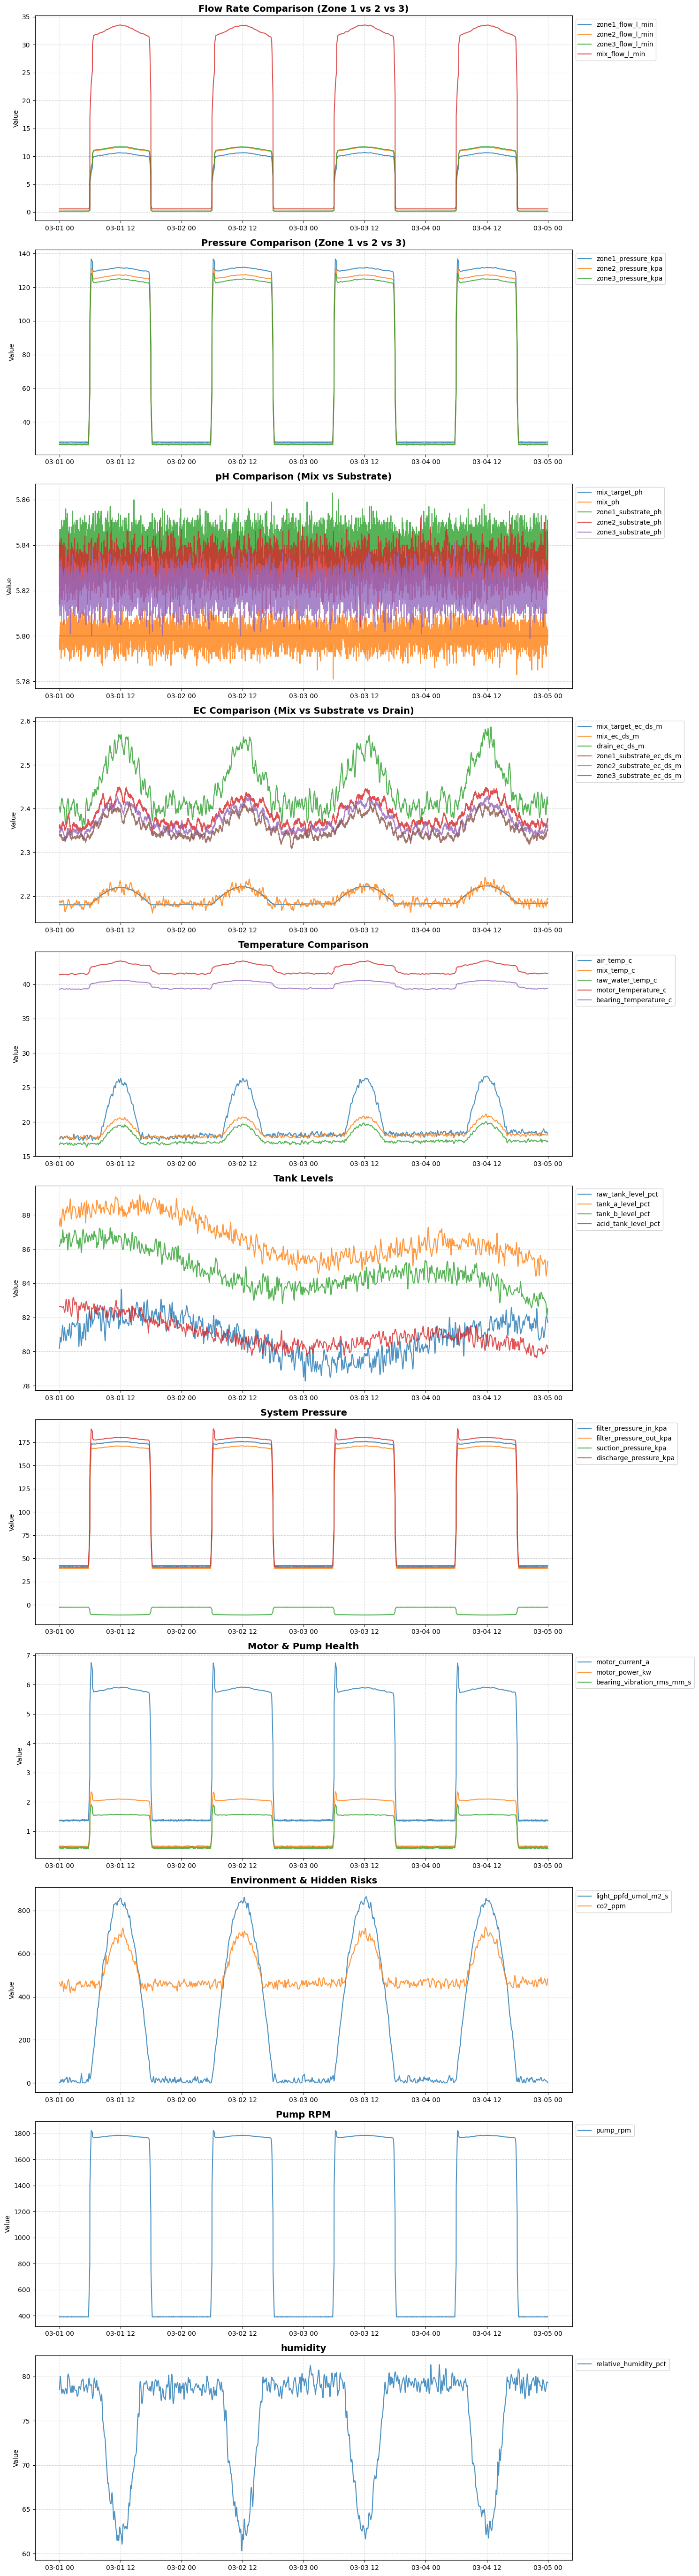

In [37]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))

minute_per_day = 60*24*2

# 이틀 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day*2] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

# 파생변수 생성 및 컬럼 삭제


In [38]:
df_copy = df_raw.copy()

In [39]:
df_copy.columns

Index(['light_ppfd_umol_m2_s', 'air_temp_c', 'relative_humidity_pct',
       'co2_ppm', 'raw_tank_level_pct', 'raw_water_temp_c', 'pump_rpm',
       'flow_rate_l_min', 'suction_pressure_kpa', 'discharge_pressure_kpa',
       'motor_current_a', 'motor_power_kw', 'bearing_vibration_rms_mm_s',
       'motor_temperature_c', 'bearing_temperature_c',
       'filter_pressure_in_kpa', 'filter_pressure_out_kpa', 'turbidity_ntu',
       'mix_target_ec_ds_m', 'mix_ec_ds_m', 'mix_target_ph', 'mix_ph',
       'mix_temp_c', 'mix_flow_l_min', 'dosing_acid_ml_min', 'drain_ec_ds_m',
       'tank_a_level_pct', 'tank_b_level_pct', 'acid_tank_level_pct',
       'zone1_flow_l_min', 'zone1_pressure_kpa',
       'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m',
       'zone1_substrate_ph', 'zone2_flow_l_min', 'zone2_pressure_kpa',
       'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m',
       'zone2_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa',
       'zone3_substrate_moisture_p

In [40]:
# remove_cols = [ "flow_baseline_l_min", "cleaning_event_flag"]

In [41]:
# df_copy = df_copy.drop(columns=remove_cols)

---
---



In [42]:
# 💻 스마트팜 예지보전 데이터 전처리 및 피처 엔지니어링 파이프라인

import pandas as pd
import numpy as np

eps = 1e-6 # 0 나누기 방지

# ==============================================================================
# 1. 유효 데이터 필터링 (낮 시간 & 관수 가동 중)
# ==============================================================================
def filter_active_periods(df):
    """
    조명이 켜져 있는 주간 시간대이면서, 실제로 펌프나 구역 밸브가 작동한 시점만 필터링합니다.
    야간이나, 낮이더라도 물을 주지 않는 대기 시간은 분석에서 제외하여 노이즈를 줄입니다.
    """
    # 조건: 조명이 켜져있고(lights_on == 1) AND (펌프가 돌거나 OR 1~3구역 밸브 중 하나라도 열림)
    active_condition = (df['lights_on'] == 1) & (
        (df['pump_on'] == 1) | 
        (df['zone1_valve_on'] == 1) | 
        (df['zone2_valve_on'] == 1) | 
        (df['zone3_valve_on'] == 1)
    )
    return df[active_condition].copy()



# ==============================================================================
# 2. 모델 학습용 파생변수 생성 (Raw 데이터 기반)
# ==============================================================================

def create_modeling_features(df):
    """
    주니어 님의 도메인 메모(List)를 100% 반영한 고도화된 파생변수 생성 함수입니다.
    이 함수는 10분 단위 집계(Aggregation)를 하기 전, 1분 단위 Raw Data 상태에서 실행해야 가장 정확합니다.
    """
    df_feat = df_copy
    eps = 1e-6
    
    # 시간 단위 변화율을 구하기 위해 인덱스의 시간차(초 단위) 계산 (연속된 데이터라 가정)
    # 인덱스가 datetime이어야 작동합니다.
    if pd.api.types.is_datetime64_any_dtype(df_feat.index):
        dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
    else:
        dt_seconds = 60 # 기본값 1분(60초)

    # =====================================================================
    # 1. 압력 & 유량 & 전력 기본 조합 지표 (해석용과 학습용 공통 사용 가능)
    # =====================================================================
    # 차압 (Differential Pressure)
    # 펌프가 실제로 물을 끌어올려 밀어낸 순수 압력 에너지입니다.
    # [Rule] 차압이 급감하면 펌프 임펠러 손상이나 공기 유입(캐비테이션)을 의심해야 합니다.
    df_feat['differential_pressure_kpa'] = df_feat['discharge_pressure_kpa'] - df_feat['suction_pressure_kpa']

    # 유량 감소율 (Flow Drop Rate)
    # 정상적인 기준치 대비 현재 유량이 얼마나 줄었는지 백분율로 나타냅니다.
    # [Rule] 유량이 급감(-)하면 공압, 실린더, 배관 막힘 등 물리적 저항이 발생했음을 의미합니다.
    # baseline은 최근 1시간(60분) 이동평균으로 설정
    df_feat['flow_baseline_l_min'] = df_feat['flow_rate_l_min'].rolling(window=60, min_periods=1).mean().shift(1)
    df_feat['flow_drop_rate'] = (df_feat['flow_baseline_l_min'] - df_feat['flow_rate_l_min']) / (df_feat['flow_baseline_l_min'] + eps)

    # =====================================================================
    # [추가] 1-2. 펌프 수력학 및 시스템 효율 지표
    # =====================================================================
    # 필터 전후 압력 차 (Filter Delta P) 
    # df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']
    # 필터 전후 압력차 유의미한 결과 뽑기 힘들어서 제거

    # 유체에 전달된 유효 동력 (Hydraulic Power, kW)
    # 수식: (유량(L/min) * 차압(kPa)) / 60,000
    df_feat['hydraulic_power_kw'] = (df_feat['flow_rate_l_min'] * df_feat['differential_pressure_kpa']) / 60000

    # 모터 입력 대비 출력 효율 (Wire-to-Water Efficiency)
    # 수식: 유효 동력 / 전기 입력 전력
    df_feat['wire_to_water_efficiency'] = df_feat['hydraulic_power_kw'] / (df_feat['motor_power_kw'] + eps)


    # =====================================================================
    # 2. 온도 & 진동 동특성 지표
    # =====================================================================
    # 초당 모터 온도 변화율 (Temperature Slope)
    # 1초당 온도가 몇 도(℃) 상승/하강하는지 나타냅니다.
    # [Rule] 모터나 베어링이 갈리거나 장기적으로 막혀 부하가 심해지면, 온도가 서서히 올라가며 이 값이 지속적인 양수(+)를 띕니다.
    df_feat['temp_slope_c_per_s'] = df_feat['motor_temperature_c'].diff() / dt_seconds

    # RPM 안정성 지수 (RPM Stability Index)
    # 목표 RPM(또는 평균 RPM) 대비 현재 RPM의 떨림 정도입니다. (여기서는 직전 10분 평균 대비 차이로 계산)
    # [Rule] 펌프에 공기가 차거나 난류가 발생하면 RPM이 목표값을 유지하지 못하고 요동칩니다.
    rpm_mean = df_feat['pump_rpm'].rolling(window=10, min_periods=1).mean()
    df_feat['rpm_stability_index'] = np.abs(df_feat['pump_rpm'] - rpm_mean) / (rpm_mean + eps)

    # =====================================================================
    # 3. 양액/수질 및 환경 고도화 지표
    # =====================================================================
    # 제어기 목표 추종 오차 (PID Error EC / pH)
    # 기계가 목표로 한 EC/pH 값과 실제 섞여서 나온 값의 차이입니다.
    # [Rule] 오차가 지속적으로 크면 조제기 밸브 노후화, 산/비료 원액 고갈, 혼합 모터 고장을 의미합니다.
    df_feat['pid_error_ec'] = df_feat['mix_ec_ds_m'] - df_feat['mix_target_ec_ds_m']
    df_feat['pid_error_ph'] = df_feat['mix_ph'] - df_feat['mix_target_ph']

    # pH 불안정성 (침전 발생 임계점 6.5 초과 여부)
    # 배관 막힘의 주원인인 '칼슘/인산 침전'이 발생하는 pH 6.5 이상의 위험 상태를 플래그(1/0)로 만듭니다.
    # [Rule] 이 플래그가 켜진 상태가 오래 유지되면, 곧 배관이 막힌다는 강력한 예지 시그널입니다.
    df_feat['ph_instability_flag'] = (df_feat['mix_ph'] > 6.5).astype(int)

    # 누적 염분 부하량 추정치 (Cumulative Salt Load)
    # 배지에서 빠져나오는 배액 EC와 들어가는 공급 EC의 차이를 의미합니다.
    # [Rule] 배액 EC가 공급 EC보다 지속적으로 높으면 염류가 축적(막힘 유발)되고, 낮으면 식물이 영양결핍 상태입니다.
    df_feat['salt_accumulation_delta'] = df_feat['drain_ec_ds_m'] - df_feat['mix_ec_ds_m']

    # 광합성 유효 광량자속 밀도 누적 프록시 (DLI Proxy)
    # 순간 광량(PPFD)을 누적하여 하루 동안 식물이 받은 총 빛의 양(DLI)을 추정합니다.
    # [Rule] 빛을 많이 받을수록 식물은 물을 많이 먹습니다. 빛은 많은데 배액률이 늘어난다면 뿌리가 죽었거나 점적 핀이 빠진 것입니다.
    # DLI 공식: PPFD * 시간(초) / 1,000,000 = mol/m²/day
    df_feat['daily_light_integral_proxy'] = (df_feat['light_ppfd_umol_m2_s'] * dt_seconds) / 1_000_000

    # 하루 누적 광량 (Daily Light Integral, mol/m²/d)
    # proxy 값을 날짜(Date) 단위로 그룹화하여 누적합(cumsum)을 구합니다.
    df_feat['daily_light_integral_mol_m2_d'] = df_feat.groupby(df_feat.index.date)['daily_light_integral_proxy'].cumsum()

    # =====================================================================
    # [추가] 3-2. 식물 환경 스트레스 지표 (VPD) 복구 완료
    # =====================================================================
    T = df_feat['air_temp_c']
    RH = df_feat['relative_humidity_pct']
    # Tetens formula 적용: 권장 VPD 범위는 0.5 ~ 1.2 kPa [cite: 30]
    e_s = 0.61078 * np.exp((17.27 * T) / (T + 237.3)) 
    df_feat['calculated_vpd_kpa'] = e_s - (e_s * (RH / 100))

    # =====================================================================
    # 4. 탱크 및 자원 소진 예측 지표
    # =====================================================================
    # 탱크 수위 변화율 (Tank Level Change Pct per Min)
    # 1분 동안 원수 탱크 수위가 몇 % 줄어드는지 소모 속도를 계산합니다.
    # [Rule] 관수를 안 하는데 수위가 줄어들면 탱크 누수이며, 펌프가 도는데 수위가 안 줄면 센서 고장이나 원수 밸브 막힘입니다.
    df_feat['raw_tank_level_change_pct_per_min'] = df_feat['raw_tank_level_pct'].diff() / (dt_seconds / 60)
    
    # A/B/산 탱크 고갈 예상 시간 (Estimated Hours to Empty)
    # 현재 소비 속도를 바탕으로 비료통이 언제 텅 빌지 예측합니다. (음수 변화량 활용)
    # [Rule] 값이 급격히 0에 수렴하면 농장주에게 비료를 타라고 알람을 주어야 합니다.
    for tank in ['tank_a', 'tank_b', 'acid_tank']:
        # 최근 10분간의 평균 감소 속도 (%/min)
        consumption_rate = -df_feat[f'{tank}_level_pct'].diff().rolling(window=10, min_periods=1).mean()
        consumption_rate = consumption_rate.clip(lower=eps) # 0 이하(채우고 있는 중) 방지
        # 남은 시간(분) = 남은 잔량 / 분당 소모량 -> 시간(Hour)으로 변환
        df_feat[f'{tank}_est_hours_to_empty'] = (df_feat[f'{tank}_level_pct'] / consumption_rate) / 60

    # =====================================================================
    # 5. 구역(Zone) 복합 제어 지표
    # =====================================================================
    # 활성 구역 개수 (Active Zone Count)
    # 현재 동시에 물이 들어가고 있는 베드의 개수입니다.
    # [Rule] 1구역만 열릴 때와 3구역이 동시에 열릴 때 펌프의 토출 압력과 유량 기준치가 달라야 합니다. (다중공선성을 막고 모델에 Context 제공)
    #df_feat['active_zone_count'] = df_feat['zone1_valve_on'] + df_feat['zone2_valve_on'] + df_feat['zone3_valve_on']

    # 공급 밸런스 지수 (Supply Balance Index)
    # 펌프가 밀어낸 총 유량 대비 각 구역으로 들어간 유량의 합의 비율입니다.
    # [Rule] 메인 펌프 유량은 100인데 구역 유량 합이 70이라면, 중간 배관 어딘가에서 누수가 발생한 것입니다.
    zone_flow_sum = df_feat['zone1_flow_l_min'] + df_feat['zone2_flow_l_min'] + df_feat['zone3_flow_l_min']
    df_feat['supply_balance_index'] = zone_flow_sum / (df_feat['flow_rate_l_min'] + eps)

    # =====================================================================
    # [추가] 5-2. 구역별 수분 반응 지표
    # =====================================================================
    # 급액 후 수분 변화량 (Moisture Response)
    # 직전 1분 대비 현재 배지 수분이 얼마나 올랐는지(+) 계산합니다.
    for i in range(1, 4):
        df_feat[f'zone{i}_moisture_response_pct'] = df_feat[f'zone{i}_substrate_moisture_pct'].diff()
        # -------------------------------------------------------------
        # [추가] 5-2. 구역별 배관 저항 및 염류 축적량 지표
        # -------------------------------------------------------------
        # 배관 저항 = 압력 / 유량 (유량이 0일 때 무한대 방지를 위해 eps 더함)
        df_feat[f'zone{i}_resistance'] = df_feat[f'zone{i}_pressure_kpa'] / (df_feat[f'zone{i}_flow_l_min'] + eps)
        
        # 염류 축적량 = 배지 측정 EC - 공급 양액 EC
        df_feat[f'zone{i}_ec_accumulation'] = df_feat[f'zone{i}_substrate_ec_ds_m'] - df_feat['mix_ec_ds_m']

    return df_feat

# ==============================================================================
# 3. 데이터 시계열 윈도우 집계 (Tumbling vs Sliding)
# ==============================================================================
# 💻 스마트팜 예지보전 데이터 전처리 및 피처 엔지니어링 파이프라인

import pandas as pd
import numpy as np

eps = 1e-6 # 0 나누기 방지

# ==============================================================================
# 1. 유효 데이터 필터링 (낮 시간 & 관수 가동 중)
# ==============================================================================
def filter_active_periods(df):
    """
    조명이 켜져 있는 주간 시간대이면서, 실제로 펌프나 구역 밸브가 작동한 시점만 필터링합니다.
    야간이나, 낮이더라도 물을 주지 않는 대기 시간은 분석에서 제외하여 노이즈를 줄입니다.
    """
    # 조건: 조명이 켜져있고(lights_on == 1) AND (펌프가 돌거나 OR 1~3구역 밸브 중 하나라도 열림)
    active_condition = (df['lights_on'] == 1) & (
        (df['pump_on'] == 1) | 
        (df['zone1_valve_on'] == 1) | 
        (df['zone2_valve_on'] == 1) | 
        (df['zone3_valve_on'] == 1)
    )
    return df[active_condition].copy()



# ==============================================================================
# 2. 모델 학습용 파생변수 생성 (Raw 데이터 기반)
# ==============================================================================

def create_modeling_features(df):
    """
    주니어 님의 도메인 메모(List)를 100% 반영한 고도화된 파생변수 생성 함수입니다.
    이 함수는 10분 단위 집계(Aggregation)를 하기 전, 1분 단위 Raw Data 상태에서 실행해야 가장 정확합니다.
    """
    df_feat = df_copy
    eps = 1e-6
    
    # 시간 단위 변화율을 구하기 위해 인덱스의 시간차(초 단위) 계산 (연속된 데이터라 가정)
    # 인덱스가 datetime이어야 작동합니다.
    if pd.api.types.is_datetime64_any_dtype(df_feat.index):
        dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
    else:
        dt_seconds = 60 # 기본값 1분(60초)

    # =====================================================================
    # 1. 압력 & 유량 & 전력 기본 조합 지표 (해석용과 학습용 공통 사용 가능)
    # =====================================================================
    # 차압 (Differential Pressure)
    # 펌프가 실제로 물을 끌어올려 밀어낸 순수 압력 에너지입니다.
    # [Rule] 차압이 급감하면 펌프 임펠러 손상이나 공기 유입(캐비테이션)을 의심해야 합니다.
    df_feat['differential_pressure_kpa'] = df_feat['discharge_pressure_kpa'] - df_feat['suction_pressure_kpa']

    # 유량 감소율 (Flow Drop Rate)
    # 정상적인 기준치 대비 현재 유량이 얼마나 줄었는지 백분율로 나타냅니다.
    # [Rule] 유량이 급감(-)하면 공압, 실린더, 배관 막힘 등 물리적 저항이 발생했음을 의미합니다.
    # baseline은 최근 1시간(60분) 이동평균으로 설정
    df_feat['flow_baseline_l_min'] = df_feat['flow_rate_l_min'].rolling(window=60, min_periods=1).mean().shift(1)
    df_feat['flow_drop_rate'] = (df_feat['flow_baseline_l_min'] - df_feat['flow_rate_l_min']) / (df_feat['flow_baseline_l_min'] + eps)

    # =====================================================================
    # [추가] 1-2. 펌프 수력학 및 시스템 효율 지표
    # =====================================================================
    # 필터 전후 압력 차 (Filter Delta P)
    df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']

    # 유체에 전달된 유효 동력 (Hydraulic Power, kW)
    # 수식: (유량(L/min) * 차압(kPa)) / 60,000
    df_feat['hydraulic_power_kw'] = (df_feat['flow_rate_l_min'] * df_feat['differential_pressure_kpa']) / 60000

    # 모터 입력 대비 출력 효율 (Wire-to-Water Efficiency)
    # 수식: 유효 동력 / 전기 입력 전력
    df_feat['wire_to_water_efficiency'] = df_feat['hydraulic_power_kw'] / (df_feat['motor_power_kw'] + eps)


    # =====================================================================
    # 2. 온도 & 진동 동특성 지표
    # =====================================================================
    # 초당 모터 온도 변화율 (Temperature Slope)
    # 1초당 온도가 몇 도(℃) 상승/하강하는지 나타냅니다.
    # [Rule] 모터나 베어링이 갈리거나 장기적으로 막혀 부하가 심해지면, 온도가 서서히 올라가며 이 값이 지속적인 양수(+)를 띕니다.
    df_feat['temp_slope_c_per_s'] = df_feat['motor_temperature_c'].diff() / dt_seconds

    # RPM 안정성 지수 (RPM Stability Index)
    # 목표 RPM(또는 평균 RPM) 대비 현재 RPM의 떨림 정도입니다. (여기서는 직전 10분 평균 대비 차이로 계산)
    # [Rule] 펌프에 공기가 차거나 난류가 발생하면 RPM이 목표값을 유지하지 못하고 요동칩니다.
    rpm_mean = df_feat['pump_rpm'].rolling(window=10, min_periods=1).mean()
    df_feat['rpm_stability_index'] = np.abs(df_feat['pump_rpm'] - rpm_mean) / (rpm_mean + eps)

    # =====================================================================
    # 3. 양액/수질 및 환경 고도화 지표
    # =====================================================================
    # 제어기 목표 추종 오차 (PID Error EC / pH)
    # 기계가 목표로 한 EC/pH 값과 실제 섞여서 나온 값의 차이입니다.
    # [Rule] 오차가 지속적으로 크면 조제기 밸브 노후화, 산/비료 원액 고갈, 혼합 모터 고장을 의미합니다.
    df_feat['pid_error_ec'] = df_feat['mix_ec_ds_m'] - df_feat['mix_target_ec_ds_m']
    df_feat['pid_error_ph'] = df_feat['mix_ph'] - df_feat['mix_target_ph']

    # pH 불안정성 (침전 발생 임계점 6.5 초과 여부)
    # 배관 막힘의 주원인인 '칼슘/인산 침전'이 발생하는 pH 6.5 이상의 위험 상태를 플래그(1/0)로 만듭니다.
    # [Rule] 이 플래그가 켜진 상태가 오래 유지되면, 곧 배관이 막힌다는 강력한 예지 시그널입니다.
    df_feat['ph_instability_flag'] = (df_feat['mix_ph'] > 6.5).astype(int)

    # 누적 염분 부하량 추정치 (Cumulative Salt Load)
    # 배지에서 빠져나오는 배액 EC와 들어가는 공급 EC의 차이를 의미합니다.
    # [Rule] 배액 EC가 공급 EC보다 지속적으로 높으면 염류가 축적(막힘 유발)되고, 낮으면 식물이 영양결핍 상태입니다.
    df_feat['salt_accumulation_delta'] = df_feat['drain_ec_ds_m'] - df_feat['mix_ec_ds_m']

    # 광합성 유효 광량자속 밀도 누적 프록시 (DLI Proxy)
    # 순간 광량(PPFD)을 누적하여 하루 동안 식물이 받은 총 빛의 양(DLI)을 추정합니다.
    # [Rule] 빛을 많이 받을수록 식물은 물을 많이 먹습니다. 빛은 많은데 배액률이 늘어난다면 뿌리가 죽었거나 점적 핀이 빠진 것입니다.
    # DLI 공식: PPFD * 시간(초) / 1,000,000 = mol/m²/day
    df_feat['daily_light_integral_proxy'] = (df_feat['light_ppfd_umol_m2_s'] * dt_seconds) / 1_000_000

    # 하루 누적 광량 (Daily Light Integral, mol/m²/d)
    # proxy 값을 날짜(Date) 단위로 그룹화하여 누적합(cumsum)을 구합니다.
    df_feat['daily_light_integral_mol_m2_d'] = df_feat.groupby(df_feat.index.date)['daily_light_integral_proxy'].cumsum()

    # =====================================================================
    # [추가] 3-2. 식물 환경 스트레스 지표 (VPD) 복구 완료
    # =====================================================================
    T = df_feat['air_temp_c']
    RH = df_feat['relative_humidity_pct']
    # Tetens formula 적용: 권장 VPD 범위는 0.5 ~ 1.2 kPa [cite: 30]
    e_s = 0.61078 * np.exp((17.27 * T) / (T + 237.3)) 
    df_feat['calculated_vpd_kpa'] = e_s - (e_s * (RH / 100))

    # =====================================================================
    # 4. 탱크 및 자원 소진 예측 지표
    # =====================================================================
    # 탱크 수위 변화율 (Tank Level Change Pct per Min)
    # 1분 동안 원수 탱크 수위가 몇 % 줄어드는지 소모 속도를 계산합니다.
    # [Rule] 관수를 안 하는데 수위가 줄어들면 탱크 누수이며, 펌프가 도는데 수위가 안 줄면 센서 고장이나 원수 밸브 막힘입니다.
    df_feat['raw_tank_level_change_pct_per_min'] = df_feat['raw_tank_level_pct'].diff() / (dt_seconds / 60)
    
    # A/B/산 탱크 고갈 예상 시간 (Estimated Hours to Empty)
    # 현재 소비 속도를 바탕으로 비료통이 언제 텅 빌지 예측합니다. (음수 변화량 활용)
    # [Rule] 값이 급격히 0에 수렴하면 농장주에게 비료를 타라고 알람을 주어야 합니다.
    for tank in ['tank_a', 'tank_b', 'acid_tank']:
        # 최근 10분간의 평균 감소 속도 (%/min)
        consumption_rate = -df_feat[f'{tank}_level_pct'].diff().rolling(window=10, min_periods=1).mean()
        consumption_rate = consumption_rate.clip(lower=eps) # 0 이하(채우고 있는 중) 방지
        # 남은 시간(분) = 남은 잔량 / 분당 소모량 -> 시간(Hour)으로 변환
        df_feat[f'{tank}_est_hours_to_empty'] = (df_feat[f'{tank}_level_pct'] / consumption_rate) / 60

    # =====================================================================
    # 5. 구역(Zone) 복합 제어 지표
    # =====================================================================
    # 활성 구역 개수 (Active Zone Count)
    # 현재 동시에 물이 들어가고 있는 베드의 개수입니다.
    # [Rule] 1구역만 열릴 때와 3구역이 동시에 열릴 때 펌프의 토출 압력과 유량 기준치가 달라야 합니다. (다중공선성을 막고 모델에 Context 제공)
    #df_feat['active_zone_count'] = df_feat['zone1_valve_on'] + df_feat['zone2_valve_on'] + df_feat['zone3_valve_on']

    # 공급 밸런스 지수 (Supply Balance Index)
    # 펌프가 밀어낸 총 유량 대비 각 구역으로 들어간 유량의 합의 비율입니다.
    # [Rule] 메인 펌프 유량은 100인데 구역 유량 합이 70이라면, 중간 배관 어딘가에서 누수가 발생한 것입니다.
    zone_flow_sum = df_feat['zone1_flow_l_min'] + df_feat['zone2_flow_l_min'] + df_feat['zone3_flow_l_min']
    df_feat['supply_balance_index'] = zone_flow_sum / (df_feat['flow_rate_l_min'] + eps)

    # =====================================================================
    # [추가] 5-2. 구역별 수분 반응 지표
    # =====================================================================
    # 급액 후 수분 변화량 (Moisture Response)
    # 직전 1분 대비 현재 배지 수분이 얼마나 올랐는지(+) 계산합니다.
    for i in range(1, 4):
        df_feat[f'zone{i}_moisture_response_pct'] = df_feat[f'zone{i}_substrate_moisture_pct'].diff()
        # -------------------------------------------------------------
        # [추가] 5-2. 구역별 배관 저항 및 염류 축적량 지표
        # -------------------------------------------------------------
        # 배관 저항 = 압력 / 유량 (유량이 0일 때 무한대 방지를 위해 eps 더함)
        df_feat[f'zone{i}_resistance'] = df_feat[f'zone{i}_pressure_kpa'] / (df_feat[f'zone{i}_flow_l_min'] + eps)
        
        # 염류 축적량 = 배지 측정 EC - 공급 양액 EC
        df_feat[f'zone{i}_ec_accumulation'] = df_feat[f'zone{i}_substrate_ec_ds_m'] - df_feat['mix_ec_ds_m']

    return df_feat

# ==============================================================================
# 3. 데이터 시계열 윈도우 집계 (Tumbling vs Sliding)
# ==============================================================================
def aggregate_time_window(df, method='tumbling', window_size='10min', slide_step='1min'):
    """
    연속된 시계열 데이터를 머신러닝 모델이 소화하기 좋게 윈도우 단위로 묶어줍니다.
    """
    # 연속형 수치 데이터만 평균(mean)으로 집계한다고 가정
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if method == 'tumbling':
        # 1. 텀블링 윈도우 (Non-overlapping)
        # 1시간을 10분씩 겹치지 않게 딱 6개로 쪼갭니다. 데이터 크기가 작아지고 학습이 빠릅니다.
        df_agg = df[numeric_cols].resample(window_size).mean()
        
    elif method == 'sliding':
        # 2. 슬라이딩 윈도우 (Overlapping)
        # 10분 크기의 창을 1분(slide_step)씩 옆으로 밀면서 집계합니다. 
        # 데이터 포인트가 많아져 AutoEncoder가 더 미세한 패턴 변화를 학습하기 좋습니다. (현업 추천)
        df_agg = df[numeric_cols].rolling(window=window_size).mean()
        # rolling은 기본적으로 데이터 주파수를 바꾸지 않으므로, step 주기로 샘플링
        df_agg = df_agg.resample(slide_step).first() 
        
    # 집계 후 결측치 발생 구간(가동 중지 구간 등) 제거
    return df_agg.dropna()

In [43]:

# ==============================================================================
# 4. 결과 해석용 파생변수 생성 (강사님 지표 분리)
# ==============================================================================

# extract_interpretation_features 함수는 텀블링 윈도우든 슬라이딩 윈도우든 전혀 수정할 필요 없이 그대로 사용하면 됨.

def extract_interpretation_features(df_agg):
    """
    AutoEncoder의 입력으로 쓰지 않고, 
    나중에 '왜 고장 징후(Anomaly)로 판별했는가?'를 해석할 때 모니터링용으로 쓸 강사님의 피처들입니다.
    윈도우 집계가 끝난 데이터(df_agg) 위에서 계산합니다.
    """
    eps = 1e-6
    df_interpret = pd.DataFrame(index=df_agg.index)
    
    # ---------------------------------------------------------
    # 1. 유량 대비 압력 비율 (Pressure Flow Ratio)
    # [Rule] 펌프 효율 저하 지표. 같은 압력을 가했는데 유량이 줄었다면 관로 막힘 의심, 반대면 누수 의심.
    df_interpret["pressure_flow_ratio"] = df_agg['discharge_pressure_kpa'] / (df_agg['flow_rate_l_min'] + eps) 

    # ---------------------------------------------------------
    # 2. 차압 대비 유량 (Differential Pressure per Flow)
    # [Rule] 토출과 흡입 압력의 차이(순수 펌프 에너지) 대비 유량. 값이 상승하면 에너지만 쓰고 물은 못 밀어내는 비정상 부하 상태입니다.
    df_interpret["dp_per_flow"] = (df_agg['discharge_pressure_kpa'] - df_agg['suction_pressure_kpa']) / (df_agg['flow_rate_l_min'] + eps)

    # ---------------------------------------------------------
    # 3. 압력 대비 전력 효율 (Pressure per Power)
    # [Rule] 압력을 유지하기 위해 전력을 과하게 쓰고 있다면 모터의 베어링 마모 등 기계적 부하가 걸린 상태입니다.
    df_interpret["pressure_per_power"]  = df_agg['discharge_pressure_kpa'] / (df_agg['motor_power_kw'] + eps)
    
    # ---------------------------------------------------------
    # 4. 유량 대비 전력 효율 (Flow per Power)
    # [Rule] 동일한 전력을 소모하는데 유량이 줄어들면, 모터나 펌프 내부의 기계적 마찰이 심해졌음을 의미합니다.
    df_interpret["flow_per_power"] = df_agg['flow_rate_l_min'] / (df_agg['motor_power_kw'] + eps)

    # ---------------------------------------------------------
    # 5. 유량 감소율 (Flow Drop Rate)
    # [Rule] 정상적인 기준치 대비 현재 얼마나 흐름이 약해졌는지 백분율로 나타냅니다.
    # 주의: 이 값은 1분 단위 원천 데이터에서 계산되어 df_agg로 넘어온 상태이므로 재계산하지 않고 가져옵니다.
    if 'flow_drop_rate' in df_agg.columns:
        df_interpret["flow_drop_rate"] = df_agg['flow_drop_rate']
    else:
        # 혹시 이전 단계에서 누락되었을 경우를 대비한 예외 처리 (10분 평균값 기반으로 임시 계산)
        flow_baseline_10m = df_agg['flow_rate_l_min'].rolling(window=6, min_periods=1).mean().shift(1)
        df_interpret["flow_drop_rate"] = (flow_baseline_10m - df_agg['flow_rate_l_min']) / (flow_baseline_10m + eps)

    return df_interpret

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import shap

# =====================================================================
# 1. 단일 타겟에 대한 모델 학습 및 SHAP 중요도 추출 함수
# =====================================================================
def get_shap_importance(X, y, target_name, n_estimators=100, random_state=42):
    print(f"[{target_name}] 모델 학습 및 SHAP 계산 중... (전체 데이터: {len(X)}개)")
    
    # 1. 모델 학습 (학습은 빠르므로 전체 데이터 43,199개 모두 사용)
    # 트리가 너무 깊어지는 것을 방지하기 위해 max_depth를 15 정도로 제한하면 훨씬 빠르고 과적합도 막아줍니다.
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=15, random_state=random_state, n_jobs=-1)
    model.fit(X, y)
    
    # 2. SHAP 값 계산 (★핵심 최적화: SHAP 계산용 데이터는 3000개만 무작위 샘플링)
    sample_size = min(3000, len(X))
    X_sample = X.sample(n=sample_size, random_state=random_state)
    
    print(f"  -> SHAP 연산 가속을 위해 {sample_size}개 샘플링 완료. 계산 시작...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # 3. 피처별 SHAP 중요도 계산
    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Importance': shap_sum
    }).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
    
    return explainer, shap_values, importance_df


def get_shap_importance_kmeans(X, y, target_name, n_estimators=100, random_state=42):

    """
    트리 기반 모델(Random Forest, XGBoost)은 데이터의 크기나 비율보다는 '순서(Rank)'를 기준으로 분기를 나누기 때문에 스케일링이 전혀 필요 없습니다.
    하지만 K-Means는 '유클리디안 거리(Euclidean Distance)'를 계산하기 때문에 스케일링을 안 하면 대참사가 일어납니다. 
    예를 들어 압력 센서는 1000 단위로 움직이고, 밸브 상태는 0~1로 움직인다면 K-Means는 압력 센서만 보고 군집을 엉터리로 나눠버립니다.
    """

    print(f"[{target_name}] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: {len(X)}개)")
    
    # 1. 모델 학습 (RF는 스케일링이 필요 없으므로 원본 데이터 X를 그대로 사용)
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=15, random_state=random_state, n_jobs=-1)
    model.fit(X, y)
    
    # =====================================================================
    # 🌟 [스케일링 및 K-Means 압축 로직]
    # =====================================================================
    print(f"  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...")
    
    # [추가됨] K-Means를 위한 임시 스케일링 (평균 0, 분산 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_clusters = min(300, len(X)) 
    
    # K-Means 모델은 '스케일링된 데이터'로 학습하여 공평하게 거리를 잼
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    kmeans.fit(X_scaled)
    
    # [추가됨] 💥 핵심: SHAP 계산 시 원래의 센서 단위(압력, 유량 등)로 해석하기 위해 
    # 스케일링된 군집 중심점들을 다시 원래 스케일로 역변환(inverse_transform) 해줍니다.
    centers_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)
    
    # 역변환된 중심점을 DataFrame으로 만듦
    X_background = pd.DataFrame(centers_original_scale, columns=X.columns)
    
    print(f"  -> 대표 패턴 {n_clusters}개 추출 및 역변환 완료. SHAP 계산 시작...")
    # =====================================================================
    
    # 3. SHAP 값 계산 (원래 스케일로 돌아온 X_background를 넣습니다)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_background, approximate=True)
    
    # 4. 피처별 SHAP 중요도 계산
    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Importance': shap_sum
    }).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
    
    return explainer, shap_values, X_background, importance_df


# =====================================================================
# 2. Multi-Target SHAP Ensemble 메인 함수
# =====================================================================
def run_shap_ensemble(df, target_dict, top_ratio=0.2):
    """
    여러 타겟에 대해 SHAP 분석을 수행하고, 상위 피처들의 교집합/합집합을 도출합니다.
    
    :param df: 전체 데이터프레임 (파생변수 포함, 결측치 처리 완료 상태)
    :param target_dict: 타겟 이름과 해당 타겟의 '누수(Leakage) 방지용 제외 컬럼'을 매핑한 딕셔너리
    :param top_ratio: 각 타겟별로 상위 몇 %의 피처를 선정할 것인지 (기본 20%)
    :return: 최종 선정된 피처 리스트, 각 타겟별 중요도 DF 딕셔너리
    """
    all_features = df.columns.tolist()
    
    importance_results = {}
    shap_values_dict = {}
    x_background_dict = {}
    
    top_features_per_target = {}
    
    # 각 타겟별로 순회하며 SHAP 추출
    for target, leak_cols in target_dict.items():
        # X, y 분리 (타겟 본인과, 타겟을 계산하는 데 쓰인 부모 컬럼들 제외)
        cols_to_drop = [target] + leak_cols
        X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
        y = df[target]
        
        # 결측치가 있으면 RF가 안 돌아가므로 임시로 평균 채우기 (이미 전처리 하셨다면 생략 가능)
        X = X.fillna(X.mean())
        y = y.fillna(y.mean())
        
        # SHAP 중요도 계산
        _, shap_vals, x_bg, imp_df = get_shap_importance_kmeans(X, y, target)
        
        # 딕셔너리에 저장
        importance_results[target] = imp_df
        shap_values_dict[target] = shap_vals
        x_background_dict[target] = x_bg
        
        # 상위 N% 피처 추출
        top_n_count = max(1, int(len(X.columns) * top_ratio))
        top_features = imp_df.head(top_n_count)['Feature'].tolist()
        top_features_per_target[target] = set(top_features)
        
        print(f"  -> 상위 {top_ratio*100}% ({top_n_count}개) 피처 선정 완료\n")

    # 3. 앙상블 논리 적용 (교집합 및 합집합)
    list_of_sets = list(top_features_per_target.values())
    
    # 교집합: 3개 고장 모드 모두에서 공통으로 중요한 핵심 피처 (가장 강력함)
    intersection_features = set.intersection(*list_of_sets)
    
    # 합집합: 하나라도 중요하다고 뜬 피처 (풀(Pool)을 넓게 가져갈 때)
    union_features = set.union(*list_of_sets)
    
    # 최소 2개 이상의 타겟에서 중요하다고 꼽힌 피처 (가장 추천하는 현실적 타협안)
    from collections import Counter
    all_selected_features = [feat for feature_set in list_of_sets for feat in feature_set]
    feature_counts = Counter(all_selected_features)
    robust_features = [feat for feat, count in feature_counts.items() if count >= 2]
    
    print("="*50)
    print("🏆 Multi-Target SHAP Ensemble 결과 요약")
    print("="*50)
    print(f"1. 교집합 (모두에서 중요): {len(intersection_features)}개")
    print(f"2. 투표(Voting, 2개 이상 타겟에서 중요): {len(robust_features)}개  <-- [AutoEncoder 추천]")
    print(f"3. 합집합 (전체 풀): {len(union_features)}개")

    # 🌟 [수정됨] 3가지 앙상블 리스트를 딕셔너리로 묶어서 반환합니다.
    ensemble_lists = {
        'intersection': list(intersection_features),
        'robust': robust_features,
        'union': list(union_features)
    }
    
    return ensemble_lists, importance_results, shap_values_dict, x_background_dict


# =====================================================================
# 3. 시각화 보조 함수 (특정 타겟의 SHAP Top 15 시각화)
# =====================================================================
def plot_shap_top_n(importance_df, target_name, top_n=15):
    plt.figure(figsize=(10, 6))
    data_to_plot = importance_df.head(top_n)
    sns.barplot(x='SHAP_Importance', y='Feature', data=data_to_plot, palette='viridis')
    plt.title(f'[{target_name}] SHAP 중요도 Top {top_n}', fontsize=15)
    plt.xlabel('Mean |SHAP value|', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/analyzer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
# ==============================================================================
# [Pipeline Step 1] 파생변수 생성 및 윈도우 집계
# ==============================================================================
def step1_prepare_window_data(df_raw, window_method='sliding'):
    print(f"⏳ [Step 1] 파생변수 생성 및 {window_method.upper()} 윈도우 집계 시작...")
    
    # 1. 로우 데이터에서 물리적 파생변수 생성 (공통)
    df_features = create_modeling_features(df_raw)
    
    # 2. 윈도우 집계 (인자에 따라 다르게 동작)
    if window_method == 'sliding':
        df_agg = aggregate_time_window(df_features, method='sliding', window_size='10min', slide_step='1min')
    elif window_method == 'tumbling':
        df_agg = aggregate_time_window(df_features, method='tumbling', window_size='10min') 
    else:
        raise ValueError("window_method는 'sliding' 또는 'tumbling' 이어야 합니다.")
        
    # 3. [해석용 데이터] 모델 피처 삭제 전, 원본 윈도우 데이터에서 미리 분리
    df_interpret = extract_interpretation_features(df_agg)
    
    print(f"  -> 집계 완료! (집계 데이터: {df_agg.shape}, 해석용 데이터: {df_interpret.shape})")
    return df_agg, df_interpret

# ==============================================================================
# [Pipeline Step 2] 데이터 정제 및 다중공선성 제거
# ==============================================================================
def step2_clean_and_drop_collinear(df_agg):
    print("\n🧹 [Step 2] 데이터 정제 및 다중공선성 변수 제거 시작...")
    df_final = df_agg.copy()

    # 1. 무한대(Inf) 및 결측치(NaN) 처리
    df_final = df_final.replace([np.inf, -np.inf], np.nan)
    df_final = df_final.fillna(df_final.mean())

    # 2. 다중공선성 및 풍선효과 결과 변수들 수동 제거 리스트
    collinear_drop_list = [
        'tank_b_level_pct', 'acid_tank_level_pct', 
        'tank_a_est_hours_to_empty', 'tank_b_est_hours_to_empty', 'acid_tank_est_hours_to_empty',
        'zone2_flow_l_min', 'zone3_flow_l_min', 
        'zone2_pressure_kpa', 'zone3_pressure_kpa',
        'zone2_substrate_moisture_pct', 'zone3_substrate_moisture_pct',
        'zone2_substrate_ec_ds_m', 'zone3_substrate_ec_ds_m',
        'zone2_resistance', 'zone3_resistance',
        'relative_humidity_pct', 'mix_temp_c', 'raw_water_temp_c',
        'mix_flow_l_min', 'filter_pressure_out_kpa', 'hidden_tip_clog_level'
    ]

    # 3. 변수 걷어내기
    df_clean = df_final.drop(columns=[col for col in collinear_drop_list if col in df_final.columns])
    print(f"  -> 중복/노이즈 변수 {len(collinear_drop_list)}개 제거 완료! (남은 피처 수: {len(df_clean.columns)})")
    
    return df_clean

# ==============================================================================
# [Pipeline Step 3 & 4] SHAP 앙상블 실행 및 최종 AE 데이터 확정
# ==============================================================================
def step3_4_select_features_and_finalize(df_clean, df_interpret, target_dict, top_ratio=0.25):
    print("\n🔍 [Step 3] 정제된 데이터로 SHAP 기반 피처 셀렉션을 시작합니다...")
    
    # 1. 앙상블 실행
    ensemble_lists, shap_results, shap_vals_dict, X_bg_dict = run_shap_ensemble(df_clean, target_dict, top_ratio=top_ratio)
    
    # 2. 결과 출력 (Phase 4 기능 통합)
    print("\n🎯 [Step 4] 선정된 핵심 피처 리스트 및 최종 오토인코더 데이터 확정")
    print("-" * 60)
    print(f"1. 교집합 피처 ({len(ensemble_lists['intersection'])}개 - 모든 고장에 관여):")
    print(ensemble_lists['intersection'])

    print(f"\n2. Robust 피처 ({len(ensemble_lists['robust'])}개 - 추천! 2개 이상 고장에 관여):")
    print(ensemble_lists['robust'])

    print(f"\n3. 합집합 피처 ({len(ensemble_lists['union'])}개 - 전체 후보군):")
    print(ensemble_lists['union'])
    print("-" * 60)

    # 3. 최종 학습용 데이터셋(X_train_ae) 구축
    X_train_ae = df_clean[ensemble_lists['robust']].copy()

    print(f"\n✅ 최종 데이터 준비 완료!")
    print(f"  - 오토인코더 학습용 데이터 (X_train_ae) 형태: {X_train_ae.shape}")
    print(f"  - 결과 해석/모니터링용 데이터 (df_interpret) 형태: {df_interpret.shape}")
    
    return X_train_ae, ensemble_lists, shap_results, shap_vals_dict, X_bg_dict


def run_feature_selection_experiment(df_raw, window_method, target_dict):
    print(f"\n" + "="*60)
    print(f"🚀 [EXPERIMENT] 시작: {window_method.upper()} WINDOW 방식")
    print("="*60)
    
    start_time = time.time()
    
    # -------------------------------------------------------------------------
    # 🧱 완벽하게 모듈화된 파이프라인 조립 (단 3단계!)
    # -------------------------------------------------------------------------
    
    # 1. 파생변수 생성 및 윈도우 집계 (내부에서 알아서 sliding/tumbling 구분)
    df_agg, df_interpret = step1_prepare_window_data(df_raw, window_method=window_method)
    
    # 2. 데이터 정제 및 다중공선성(노이즈) 제거
    df_clean = step2_clean_and_drop_collinear(df_agg)
    
    # 3. SHAP 앙상블 실행 및 최종 데이터셋 생성 (밖에서 받아온 target_dict 사용)
    X_train_ae, ensemble_lists, shap_results, shap_vals_dict, X_bg_dict = step3_4_select_features_and_finalize(
        df_clean, df_interpret, target_dict, top_ratio=0.25
    )
    
    robust_features = ensemble_lists['robust']
    end_time = time.time()
    
    print(f"\n✅ [{window_method.upper()}] 실험 완료!")
    
    return robust_features, X_train_ae, df_interpret, shap_results

In [54]:
# ==============================================================================
# ⚔️ [메인 실행 블록] Sliding vs Tumbling A/B 테스트 및 시각화
# ==============================================================================
# 1. 타겟 딕셔너리 세팅
target_dictionary = {
    'motor_current_a': ['motor_power_kw', 'wire_to_water_efficiency','motor_temperature_c'], 
    'zone1_resistance': ['zone1_pressure_kpa', 'zone1_flow_l_min'],
    'wire_to_water_efficiency': ['motor_power_kw', 'differential_pressure_kpa', 'flow_rate_l_min', 'hydraulic_power_kw']
}

print("🏁 윈도우 집계 방식론(Sliding vs Tumbling) A/B 테스트를 시작합니다.")

# 2. Tumbling 방식 실행 (주의: 리턴값 4개로 받기!)
features_tumbling, X_train_tumbling, interpret_tumbling, shap_res_tumbling = run_feature_selection_experiment(
    df_raw=df_copy, 
    window_method='tumbling', 
    target_dict=target_dictionary
)

# 3. Sliding 방식 실행 (주의: 리턴값 4개로 받기!)
features_sliding, X_train_sliding, interpret_sliding, shap_res_sliding = run_feature_selection_experiment(
    df_raw=df_copy, 
    window_method='sliding', 
    target_dict=target_dictionary
)

# ==============================================================================
# 📊 [파트 1: 결과 비교 분석 리포트 - Text]
# ==============================================================================
print("\n\n" + "★"*60)
print("🏆 [텍스트 리포트] SLIDING vs TUMBLING 추출 피처 비교")
print("★"*60)

set_tumbling = set(features_tumbling)
set_sliding = set(features_sliding)

print(f"\n[1] 추출된 데이터 크기 (Data Size)")
print(f"  - Tumbling (거시적 트렌드): {X_train_tumbling.shape[0]} rows")
print(f"  - Sliding (미세 전조증상): {X_train_sliding.shape[0]} rows")

print(f"\n[2] 공통으로 뽑힌 절대 피처 (Intersection: {len(set_tumbling & set_sliding)}개)")
print("  :", list(set_tumbling & set_sliding))

print(f"\n[3] Sliding 윈도우에서만 포착된 피처 (Only in Sliding: {len(set_sliding - set_tumbling)}개)")
print("  :", list(set_sliding - set_tumbling))

print(f"\n[4] Tumbling 윈도우에서만 포착된 피처 (Only in Tumbling: {len(set_tumbling - set_sliding)}개)")
print("  :", list(set_tumbling - set_sliding))
print("★"*60)

🏁 윈도우 집계 방식론(Sliding vs Tumbling) A/B 테스트를 시작합니다.

🚀 [EXPERIMENT] 시작: TUMBLING WINDOW 방식
⏳ [Step 1] 파생변수 생성 및 TUMBLING 윈도우 집계 시작...
  -> 집계 완료! (집계 데이터: (12960, 73), 해석용 데이터: (12960, 5))

🧹 [Step 2] 데이터 정제 및 다중공선성 변수 제거 시작...
  -> 중복/노이즈 변수 21개 제거 완료! (남은 피처 수: 53)

🔍 [Step 3] 정제된 데이터로 SHAP 기반 피처 셀렉션을 시작합니다...
[motor_current_a] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: 12960개)
  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...
  -> 대표 패턴 300개 추출 및 역변환 완료. SHAP 계산 시작...
  -> 상위 25.0% (12개) 피처 선정 완료

[zone1_resistance] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: 12960개)
  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...
  -> 대표 패턴 300개 추출 및 역변환 완료. SHAP 계산 시작...
  -> 상위 25.0% (12개) 피처 선정 완료

[wire_to_water_efficiency] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: 12960개)
  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...
  -> 대표 패턴 300개 추출 및 역변환 완료. SHAP 계산 시작...
  -> 상위 25.0% (12개) 피처 선정 완료

🏆 Multi-Target SHAP Ensemble 결과 요약
1. 교집합 (모두에서 중요): 2개
2. 투표(Voting, 2개 이상 타겟에서 중요): 11개  <-- [AutoEncoder 추천]
3. 합집합 (전체 

In [48]:
print(df_copy.shape)
df_copy.head(3)

(129591, 44)


,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_rate_l_min,suction_pressure_kpa,discharge_pressure_kpa,...,zone2_flow_l_min,zone2_pressure_kpa,zone2_substrate_moisture_pct,zone2_substrate_ec_ds_m,zone2_substrate_ph,zone3_flow_l_min,zone3_pressure_kpa,zone3_substrate_moisture_pct,zone3_substrate_ec_ds_m,zone3_substrate_ph
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-01 00:00:00,2.252,17.538,78.516,464.921,80.184,16.680,392.161,0.575,-2.465,42.114,...,0.18,26.914,57.930,2.344,5.822,0.182,26.685,58.016,2.341,5.814
2026-03-01 00:01:00,2.134,17.539,78.614,464.468,80.224,16.697,392.065,0.575,-2.466,42.005,...,0.18,27.043,57.931,2.345,5.835,0.183,26.556,58.020,2.340,5.819
2026-03-01 00:02:00,2.010,17.541,78.718,463.988,80.268,16.715,391.248,0.574,-2.474,42.035,...,0.18,27.005,57.933,2.346,5.829,0.183,26.622,58.024,2.341,5.813


In [49]:
# ==============================================================================
# 👀 [파트 2: 결과 비교 시각화 리포트 - Visual]
# ==============================================================================
# 나란히 비교하는 시각화 함수 정의 (Seaborn 경고 방지를 위해 hue 옵션 추가)
def compare_shap_visualizations(shap_res_tumb, shap_res_slid, target_name, top_n=10):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 왼쪽: Tumbling 그래프
    data_tumb = shap_res_tumb[target_name].head(top_n)
    sns.barplot(x='SHAP_Importance', y='Feature', hue='Feature', data=data_tumb, ax=axes[0], palette='Blues_r', legend=False)
    axes[0].set_title(f'[Tumbling] {target_name} Top {top_n}', fontsize=14)
    axes[0].set_xlabel('Mean |SHAP value|')
    
    # 오른쪽: Sliding 그래프
    data_slid = shap_res_slid[target_name].head(top_n)
    sns.barplot(x='SHAP_Importance', y='Feature', hue='Feature', data=data_slid, ax=axes[1], palette='Oranges_r', legend=False)
    axes[1].set_title(f'[Sliding] {target_name} Top {top_n}', fontsize=14)
    axes[1].set_xlabel('Mean |SHAP value|')
    
    plt.tight_layout()
    plt.show() # Jupyter 환경에서 그래프를 즉시 렌더링

print("\n" + "="*60)
print("👀 [시각화 리포트] Tumbling(좌측/파란색) vs Sliding(우측/주황색) 비교")
print("="*60)

# 3가지 타겟에 대해 모두 듀얼 그래프 출력
for target in target_dictionary.keys():
    compare_shap_visualizations(shap_res_tumbling, shap_res_sliding, target, top_n=10)


👀 [시각화 리포트] Tumbling(좌측/파란색) vs Sliding(우측/주황색) 비교


NameError: name 'shap_res_tumbling' is not defined

In [50]:
# ==============================================================================
# 👀 [최종 리포트 시각화] Sliding 윈도우 3개 타겟 SHAP 결과 요약 (1x3 Layout)
# ==============================================================================
def plot_sliding_shap_only(shap_res_slid, target_dict, top_n=10):
    # 타겟 이름들을 리스트로 추출 (정확히 3개)
    targets = list(target_dict.keys())
    n_targets = len(targets)
    
    # 1행 3열의 도화지 준비 (가로로 넓게 20x6 사이즈 지정)
    fig, axes = plt.subplots(1, n_targets, figsize=(20, 6))
    
    # 각 타겟별로 순회하며 그래프 그리기
    for i, target_name in enumerate(targets):
        # 1. 상위 N개 데이터 추출
        data_slid = shap_res_slid[target_name].head(top_n)
        
        # 2. 바 차트 그리기 (axes[i]에 순서대로 할당)
        sns.barplot(
            x='SHAP_Importance', 
            y='Feature', 
            hue='Feature', 
            data=data_slid, 
            ax=axes[i], 
            palette='Oranges_r', # Sliding을 상징하는 주황색 톤
            legend=False
        )
        
        # 3. 타이틀 및 라벨 정리
        axes[i].set_title(f'[Sliding] {target_name} Top {top_n}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Mean |SHAP value|', fontsize=11)
        
        # Y축 라벨('Feature') 글자는 굳이 필요 없으니 깔끔하게 삭제
        axes[i].set_ylabel('') 

    # 그래프 간의 간격 자동 조절
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 🚀 실행 블록
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("🏆 [최종 요약 리포트] Sliding 윈도우 기반 타겟별 핵심 원인(SHAP) Top 10")
print("="*80)

# 아까 얻어둔 shap_res_sliding 변수를 그대로 집어넣습니다.
plot_sliding_shap_only(shap_res_sliding, target_dictionary, top_n=10)


🏆 [최종 요약 리포트] Sliding 윈도우 기반 타겟별 핵심 원인(SHAP) Top 10


NameError: name 'shap_res_sliding' is not defined

1. 전체 돌렸을 때, 평균값은 얼마고 , 최대는 얼마고 

2. 평균보다 전부 낮으면 무조건 탈락
3. 평균이상인 것 중에서 가장 높은 신뢰 스코어 가지면 좋은 것,
4. 가장 높지 않아도, negative영역이 summary영역이 가장 적은 것.
5. david golden  중심에서 얼마나 멀리 있는지 이게 가장 적은 클러스터. 

2~5번까지 가장 투표를 많이 받은 k 값이 최고의 k.

DBscan 을 쓰면 EPS range로 움직이는 것. 
-1 에 해당하는 element가 적으면 적을 수록 좋은 것

제대로 클러스터링 안되면 값 엉뚱하게 나올 수 있으니까, 


Tumbling의 한계 (데이터 스무딩 현상): Tumbling은 10분 치 데이터를 모아서 하나의 평균값으로 퉁칩니다. 만약 10분 중 1분 동안만 배관이 살짝 막혀서 압력이 튀었다가 돌아왔다면, 평균을 내는 순간 그 '미세한 고장 전조(Anomaly)'는 정상 데이터에 묻혀서 사라져 버립니다.

Sliding의 강력함 (고해상도 추적): 반면 Sliding은 1분 단위로 계속 창을 밀어가며 겹쳐서 분석하므로, 미세한 변화를 놓치지 않습니다.

결정적 증거: Sliding에서만 flow_drop_rate(유량 감소율)과 motor_temperature_c(모터 온도), zone1_resistance(구역 저항)가 뽑힌 것을 보세요! 배관이 막히기 시작할 때 생기는 '순간적인 유량 감소'와 부하로 인한 '모터 온도의 서서히 오르는 미세 변화'는 예지보전에서 가장 중요한 골든타임 시그널입니다. Tumbling은 이 소중한 시그널을 평균의 함정으로 다 뭉개버린 겁니다.

In [198]:
pltfont.auto()

✅ 현재 폰트 적용됨: Arial Unicode MS


Multi-Target SHAP Ensemble

1. 세가지 Random Forest 만들기 
- 모델 A의 타겟: filter_delta_p_kpa (메인 배관 막힘 모델)

- 모델 B의 타겟: zone1_flow_resistance (구역 미세 막힘 모델)

- 모델 C의 타겟: wire_to_water_efficiency (펌프 기계 노후화 모델)

2. 모델에서 SHAP 중요도를 뽑습니다

3. 최종 피쳐 선정 논리
최종 피처 선정 논리: "이 세 가지 서로 다른 고장 모드(기계, 배관, 국소막힘)에서 공통적으로 SHAP 중요도 상위 20%에 랭크된 교집합(또는 합집합) 피처들을 최종 AutoEncoder의 Input으로 선정하였다. 이를 통해 특정 고장 모드에 편향되지 않은 강건한(Robust) 이상 탐지 모델을 구축할 수 있다."


🚨 데이터 누수(Data Leakag) 주의 : 

filter_delta_p_kpa를 타겟(y)으로 잡았을 때, 
입력 피처(X)에 filter_pressure_in_kpa나 filter_pressure_out_kpa가 남아있으면 안 됩니다. 
타겟이 저 두 값의 뺄셈으로 만들어졌기 때문에, RF 모델이 "아! 입구 압력에서 출구 압력을 빼면 정답이네?" 하고 수식만 100% 학습해 버립니다. 
진짜 우리가 알고 싶은 "모터 진동이나 유량이 막힘에 어떤 영향을 주는지"는 SHAP 밸류가 0으로 나와버리죠.

따라서 각 타겟마다 '정답을 스포일러 하는 부모 변수들'을 X에서 제외하고 학습하는 로직을 코드에 완벽하게 녹여내야 합니다.

K-Means 사용 근가

💡 근거 1: 스마트팜 시계열 데이터의 '자기상관성(Autocorrelation)' 한계 극복

스마트팜 데이터는 1분 혹은 5분 단위로 쌓입니다. 낮 시간대의 온도 25℃, 습도 70% 상태는 아마 1시간 동안 거의 변하지 않고 수십 개의 데이터 포인트로 쌓여 있을 겁니다.
만약 43,000개에서 무작위로 3,000개를 뽑으면, 결국 똑같은 상태(낮 시간대 평시 상태)의 복제본 데이터만 잔뜩 뽑히게 됩니다. 이는 연산량만 낭비할 뿐, 모델이 다양한 고장 조건을 해석하는 데 전혀 도움이 되지 않습니다.

💡 근거 2: 데이터의 '다양성(Variance)' 보존

K-Means 클러스터링을 사용하여 300개의 중심점(Centroid)을 뽑는다는 것은, 전체 43,000개의 데이터를 300개의 '대표 상태(Archetype)'로 요약한다는 뜻입니다.

- 상태 A: 낮, 펌프 가동 중, 필터 압력 높음
- 상태 B: 밤, 펌프 정지, 온도 낮음 
- 상태 C: 양액 공급 중, EC 변화 발생 

무작위로 뽑으면 희귀한 이상 상태(고장 전조)가 뽑히지 않을 확률이 높지만, K-Means를 쓰면 전체 데이터가 가진 모든 군집의 특성을 골고루 반영한 300개의 대표 선수들만 깔끔하게 추려낼 수 있습니다.

💡 근거 3: SHAP 논문 저자의 공식 권장 사항 (학술적 근거)

SHAP 알고리즘을 만든 스콧 룬드버그(Scott Lundberg) 교수 팀 역시, SHAP의 Background 데이터(기준이 되는 데이터)를 설정할 때 무작위 추출보다는 K-Means 알고리즘을 통해 데이터를 요약할 것을 공식 문서와 논문에서 권장하고 있습니다. (실제로 shap.kmeans(X, K) 라는 전용 함수를 라이브러리 내부에 만들어두기까지 했습니다.)

🗣️ 현업용 요약 멘트 (발표용):

"스마트팜 센서 데이터는 연속적이라 무작위로 샘플링하면 중복 데이터가 너무 많아 연산이 비효율적입니다. 따라서 전체 데이터의 분산을 최대한 유지하면서 핵심 패턴만 300개의 군집으로 요약하는 K-Means 샘플링을 적용하여, 정보 손실 없이 SHAP 연산 속도를 극대화했습니다."

---

robust_features (투표 기반 앙상블)를 쓰는 이유

run_shap_ensemble 함수에서 우리는 세 가지 피처 리스트(교집합, 투표-robust, 합집합)를 도출했습니다. 그중에서 왜 하필 robust_features (최소 2개 이상의 타겟에서 중요하다고 꼽힌 피처)를 최종 오토인코더(AutoEncoder) 학습용으로 추천할까요?

교집합(Intersection)의 한계: "모든 고장 모드에서 공통으로 중요한 피처"만 뽑으면 조건이 너무 엄격합니다. 보통 5~6개밖에 안 뽑혀서, 신경망(AutoEncoder)이 복잡한 패턴을 학습하기엔 정보량이 너무 부족해집니다.

합집합(Union)의 한계: "하나라도 중요하면 다 가져와" 방식은 조건이 너무 느슨합니다. 특정 고장 모드에만 국한된 노이즈성 센서까지 다 끌고 들어와서 모델 성능을 저하시킬 수 있습니다.

투표(Robust/Voting)의 장점: "최소 2곳 이상의 치명적 고장 상황에서 전조 증상으로 나타나는 센서"만 추리는 방식입니다. 보통 15~20개 내외의 '알짜배기 피처'들이 선별되며, 특정 고장에 편향되지 않으면서도 시스템 전체의 상태를 잘 대변하는 최적의 균형점(Sweet Spot)을 제공합니다. 현업 예지보전에서는 이 방식이 가장 안정적인 성능을 냅니다.

In [199]:
# ==============================================================================
# 🎯 [최종 확정] 오토인코더(AE) 학습용 데이터셋 바통 터치!
# ==============================================================================
# 우리는 A/B 테스트 결과, 고해상도로 미세 전조증상을 잡아내는 'Sliding' 방식을 선택합니다.
X_train_ae = X_train_sliding.copy()
df_interpret_final = interpret_sliding.copy() # 해석용 데이터도 Sliding 버전으로 맞춤

print("\n" + "="*60)
print(f"✅ 최종 오토인코더 입력 피처 {X_train_ae.shape[1]}개 확정 완료!")
print(f"  - X_train_ae 데이터 형태: {X_train_ae.shape}")
print(f"  - df_interpret_final 형태: {df_interpret_final.shape}")
print("="*60)


✅ 최종 오토인코더 입력 피처 9개 확정 완료!
  - X_train_ae 데이터 형태: (129590, 9)
  - df_interpret_final 형태: (129590, 5)


# 모델링

Step 5-1: 데이터 스케일링 및 검증셋 분리

딥러닝은 데이터의 '스케일(단위)'에 매우 민감합니다. 0~1 사이로 예쁘게 압축해 주는 과정이 필수입니다.

In [200]:

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

print("🛠️ [Phase 5-1] 딥러닝을 위한 데이터 스케일링 및 분리...")

# 1. 스케일러 정의 (0~1 압축)
scaler = MinMaxScaler()

# 2. X_train_ae 데이터 스케일링
X_scaled = scaler.fit_transform(X_train_ae)

# 3. 모델이 '과적합(Overfitting)' 되지 않도록 학습(Train)과 검증(Val) 데이터로 분리 (8:2 비율)
# 스마트팜 데이터 특성상, 정상 패턴 학습을 위해 무작위 분리(shuffle=True)를 주로 사용합니다.
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42, shuffle=True)

print(f"✅ 데이터 분리 완료! (학습용: {X_train.shape}, 검증용: {X_val.shape})")

🛠️ [Phase 5-1] 딥러닝을 위한 데이터 스케일링 및 분리...
✅ 데이터 분리 완료! (학습용: (103672, 9), 검증용: (25918, 9))


Step 5-2: AutoEncoder 모델 아키텍처 설계

텐서플로우의 Keras API를 사용해 "10차원 ➡️ 8 ➡️ 4 (병목) ➡️ 8 ➡️ 10차원" 형태의 모래시계 네트워크를 만듭니다.

In [201]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

print("\n🧠 [Phase 5-2] 텐서플로우 AutoEncoder 모델 구조 설계...")

input_dim = X_train.shape[1]

# 1. 인코더 (Encoder): 핵심 패턴으로 데이터 압축
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
# Dropout을 살짝 줘서 모델이 특정 센서에만 너무 의존하지 않게(강건하게) 만듭니다.
encoded = Dropout(0.1)(encoded) 
encoded = Dense(4, activation='relu')(encoded) # ⬅️ 병목(Bottleneck) 구간

# 2. 디코더 (Decoder): 압축된 정보를 바탕으로 원본 복원
decoded = Dense(8, activation='relu')(encoded)
# 마지막 층은 MinMaxScaler(0~1)를 썼으므로 sigmoid(0~1)를 사용해 범위를 맞춰줍니다.
output_layer = Dense(input_dim, activation='sigmoid')(decoded) 

# 3. 최종 모델 정의 및 컴파일
autoencoder = Model(inputs=input_layer, outputs=output_layer)
# 이상 탐지 복원 오차는 보통 평균제곱오차(MSE)를 사용합니다.
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary() # 모델 뼈대 눈으로 확인!


🧠 [Phase 5-2] 텐서플로우 AutoEncoder 모델 구조 설계...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 9)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237 (948.00 B)

 Trainable params: 237 (948.00 B)

 Non-trainable params: 0 (0.00 B)

Step 5-3: 모델 학습 및 조기 종료 (Early Stopping)

모델이 알아서 최적의 타이밍에 학습을 멈추도록 EarlyStopping 콜백을 달아줍니다.


🚀 [Phase 5-3] AutoEncoder 모델 학습 시작...
Epoch 1/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 2s 506us/step - loss: 0.0289 - val_loss: 0.0069
Epoch 2/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 443us/step - loss: 0.0085 - val_loss: 0.0060
Epoch 3/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 446us/step - loss: 0.0067 - val_loss: 0.0050
Epoch 4/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 452us/step - loss: 0.0053 - val_loss: 0.0033
Epoch 5/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - loss: 0.0037 - val_loss: 0.0019
Epoch 6/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 441us/step - loss: 0.0028 - val_loss: 0.0015
Epoch 7/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 451us/step - loss: 0.0025 - val_loss: 0.0013
Epoch 8/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 441us/step - loss: 0.0024 - val_loss: 0.0013
Epoch 9/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 438us/step - loss: 0.0022 - val_loss: 0.0013
Epoch 10/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 449us/step - loss: 0.0022 - val_loss: 0.0014
Epoch 11/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 448

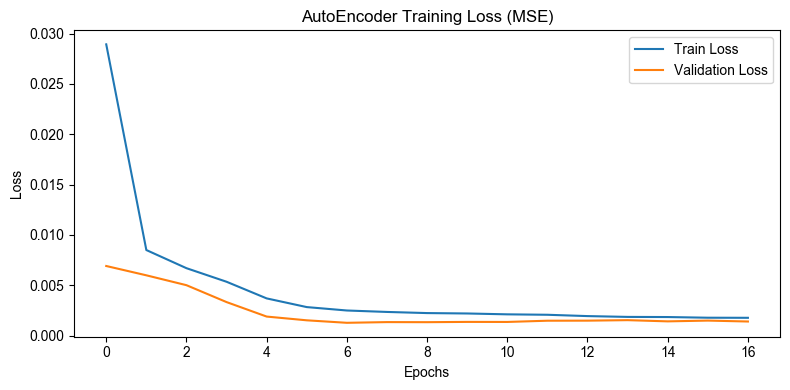

In [202]:

print("\n🚀 [Phase 5-3] AutoEncoder 모델 학습 시작...")

# 검증 손실(val_loss)이 10번 연속 안 떨어지면 학습을 스톱하고 가장 좋았던 가중치로 복구
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 학습 (입력값과 정답값이 모두 X_train으로 동일함에 주의!)
history = autoencoder.fit(
    X_train, X_train,
    epochs=100,           # 최대 100번 반복
    batch_size=64,        # 64개씩 묶어서 학습
    validation_data=(X_val, X_val), # 검증셋으로 매 에포크마다 성능 체크
    callbacks=[early_stopping],
    verbose=1
)

# 학습 경과(Loss) 시각화: 파란선과 주황선이 같이 예쁘게 떨어져야 정상입니다.
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('AutoEncoder Training Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Step 5-4: 재건 오차(Reconstruction Error) 계산 및 임계값(Threshold) 확정

이 부분이 예지보전의 꽃입니다. "도대체 오차가 몇일 때 고장(Anomaly)이라고 알람을 울릴 것인가?"를 수학적으로 결정합니다.

In [203]:
df_interpret_final

,pressure_flow_ratio,dp_per_flow,pressure_per_power,flow_per_power,flow_drop_rate
timestamp,,,,,
2026-03-01 00:01:00,67.651681,66.906798,169.991282,2.512692,-0.041666
2026-03-01 00:02:00,66.118678,65.505357,173.990843,2.631440,-0.051445
2026-03-01 00:03:00,64.650693,64.160507,178.220096,2.756608,-0.060962
2026-03-01 00:04:00,63.237245,62.864176,182.678740,2.888728,-0.070231
2026-03-01 00:05:00,61.876191,61.615190,187.389292,3.028398,-0.079261
...,...,...,...,...,...
2026-05-29 23:46:00,42.986348,44.915642,68.562243,1.594956,-0.396687
2026-05-29 23:47:00,43.726935,45.656803,68.019177,1.555524,-0.373780
2026-05-29 23:48:00,44.868313,46.825043,67.484401,1.504034,-0.336096



🎯 [Phase 5-4] 이상 탐지 임계값(Threshold) 설정...
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1s 225us/step
✅ 오토인코더 학습 완료!
  -> 정상 데이터 평균 오차: 0.001324
  -> 🚨 이상 탐지 기준점 (상위 5% 임계값): 0.002940


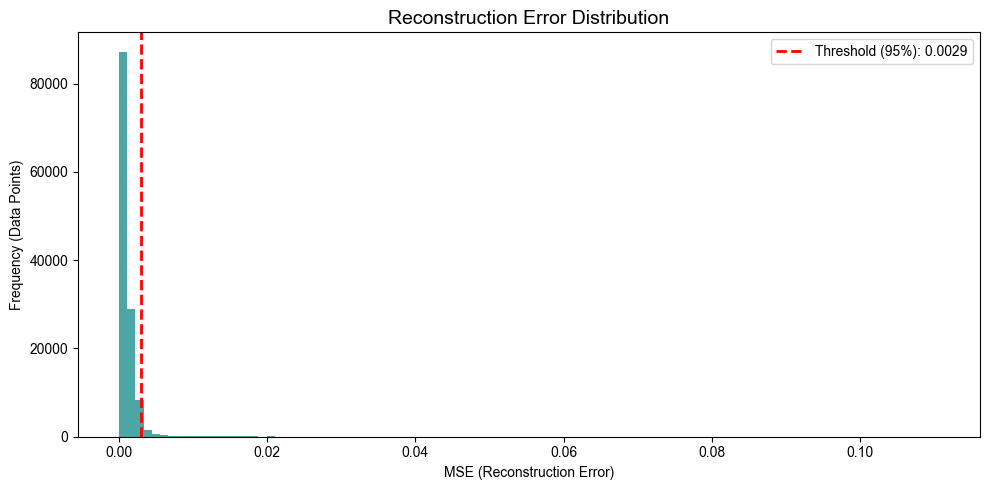

In [204]:
print("\n🎯 [Phase 5-4] 이상 탐지 임계값(Threshold) 설정...")

# 1. 전체 데이터(X_scaled)를 모델에 넣고 복원(예측)해 봅니다.
reconstructed = autoencoder.predict(X_scaled)

# 2. 원본과 복원본의 차이(MSE)를 각 데이터 샘플(행)마다 계산합니다.
mse_scores = np.mean(np.power(X_scaled - reconstructed, 2), axis=1)

# 3. 임계값 설정 (예: 전체 데이터 중 상위 5%의 오차를 가진 구간을 고장/이상으로 간주)
# 현업에서는 보통 95% ~ 99% 선에서 보수적으로 셋팅합니다.
threshold_95 = np.percentile(mse_scores, 95)

print(f"✅ 오토인코더 학습 완료!")
print(f"  -> 정상 데이터 평균 오차: {np.mean(mse_scores):.6f}")
print(f"  -> 🚨 이상 탐지 기준점 (상위 5% 임계값): {threshold_95:.6f}")

# 오차 분포를 눈으로 확인 (Threshold 선 긋기)
plt.figure(figsize=(10, 5))
plt.hist(mse_scores, bins=100, alpha=0.7, color='teal')
plt.axvline(threshold_95, color='red', linestyle='dashed', linewidth=2, label=f'Threshold (95%): {threshold_95:.4f}')
plt.title('Reconstruction Error Distribution', fontsize=14)
plt.xlabel('MSE (Reconstruction Error)')
plt.ylabel('Frequency (Data Points)')
plt.legend()
plt.tight_layout()
plt.show()

# 최종 이상치 판별 컬럼을 원본 데이터프레임에 추가
df_interpret_final['ae_mse_score'] = mse_scores
df_interpret_final['is_anomaly'] = mse_scores > threshold_95

# 테스트

In [205]:
print("🚨 [Phase 6] 3단계 알람 시스템 및 디바운싱(연속 발생) 로직 적용...")

# -------------------------------------------------------------------------
# 1. 임계값(Threshold) 3단계 세팅 (분포를 보고 수동 조절 가능)
# -------------------------------------------------------------------------
thresh_caution = np.percentile(mse_scores, 85) # 상위 15% (주의)
thresh_warning = np.percentile(mse_scores, 95) # 상위 5%  (경고)
thresh_error   = np.percentile(mse_scores, 99) # 상위 1%  (위험/에러)

print(f"🔸 주의(Caution) 기준선: {thresh_caution:.6f}")
print(f"🟠 경고(Warning) 기준선: {thresh_warning:.6f}")
print(f"🔴 에러(Error)   기준선: {thresh_error:.6f}")

# -------------------------------------------------------------------------
# 2. 1차 원시 상태(Raw State) 부여
# -------------------------------------------------------------------------
def get_raw_state(mse):
    if mse >= thresh_error:   return 3 # Error
    elif mse >= thresh_warning: return 2 # Warning
    elif mse >= thresh_caution: return 1 # Caution
    else:                       return 0 # Normal

df_interpret_final['raw_state'] = df_interpret_final['ae_mse_score'].apply(get_raw_state)

# -------------------------------------------------------------------------
# 3. 알람 승격 로직 (N번 연속 발생 시 윗 단계로 업그레이드)
# -------------------------------------------------------------------------
N_STRIKE = 3 # 3번(예: 3분) 연속 지속되면 상태 격상!

# N번 연속 '주의(1)' 이상인가?
is_caution_streak = (df_interpret_final['raw_state'] >= 1).rolling(window=N_STRIKE).sum() == N_STRIKE
# N번 연속 '경고(2)' 이상인가?
is_warning_streak = (df_interpret_final['raw_state'] >= 2).rolling(window=N_STRIKE).sum() == N_STRIKE

# 최종 알람 컬럼 복사
df_interpret_final['final_alarm_level'] = df_interpret_final['raw_state'].copy()

# 승격(Escalation) 적용
# 1) 주의가 N번 연속되면 -> 경고(2)로 승격
df_interpret_final.loc[is_caution_streak & (df_interpret_final['final_alarm_level'] < 2), 'final_alarm_level'] = 2
# 2) 경고가 N번 연속되면 -> 에러(3)로 승격
df_interpret_final.loc[is_warning_streak & (df_interpret_final['final_alarm_level'] < 3), 'final_alarm_level'] = 3

# 숫자를 알아보기 쉬운 라벨로 변경
alarm_dict = {0: 'Normal', 1: 'Caution 🔸', 2: 'Warning 🟠', 3: 'Error 🔴'}
df_interpret_final['final_alarm_label'] = df_interpret_final['final_alarm_level'].map(alarm_dict)

print(f"\n✅ 알람 로직 적용 완료! (N={N_STRIKE} 연속 발생 시 승격)")
print(df_interpret_final['final_alarm_label'].value_counts())

🚨 [Phase 6] 3단계 알람 시스템 및 디바운싱(연속 발생) 로직 적용...
🔸 주의(Caution) 기준선: 0.001836
🟠 경고(Warning) 기준선: 0.002940
🔴 에러(Error)   기준선: 0.016522

✅ 알람 로직 적용 완료! (N=3 연속 발생 시 승격)
final_alarm_label
Normal       110151
Warning 🟠     13293
Error 🔴        5548
Caution 🔸       598
Name: count, dtype: int64


In [206]:
df_interpret_final.columns

Index(['pressure_flow_ratio', 'dp_per_flow', 'pressure_per_power',
       'flow_per_power', 'flow_drop_rate', 'ae_mse_score', 'is_anomaly',
       'raw_state', 'final_alarm_level', 'final_alarm_label'],
      dtype='object')

👀 [로그 버전] 그래프 출력


/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_27485/3001324870.py:79: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/analyzer/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


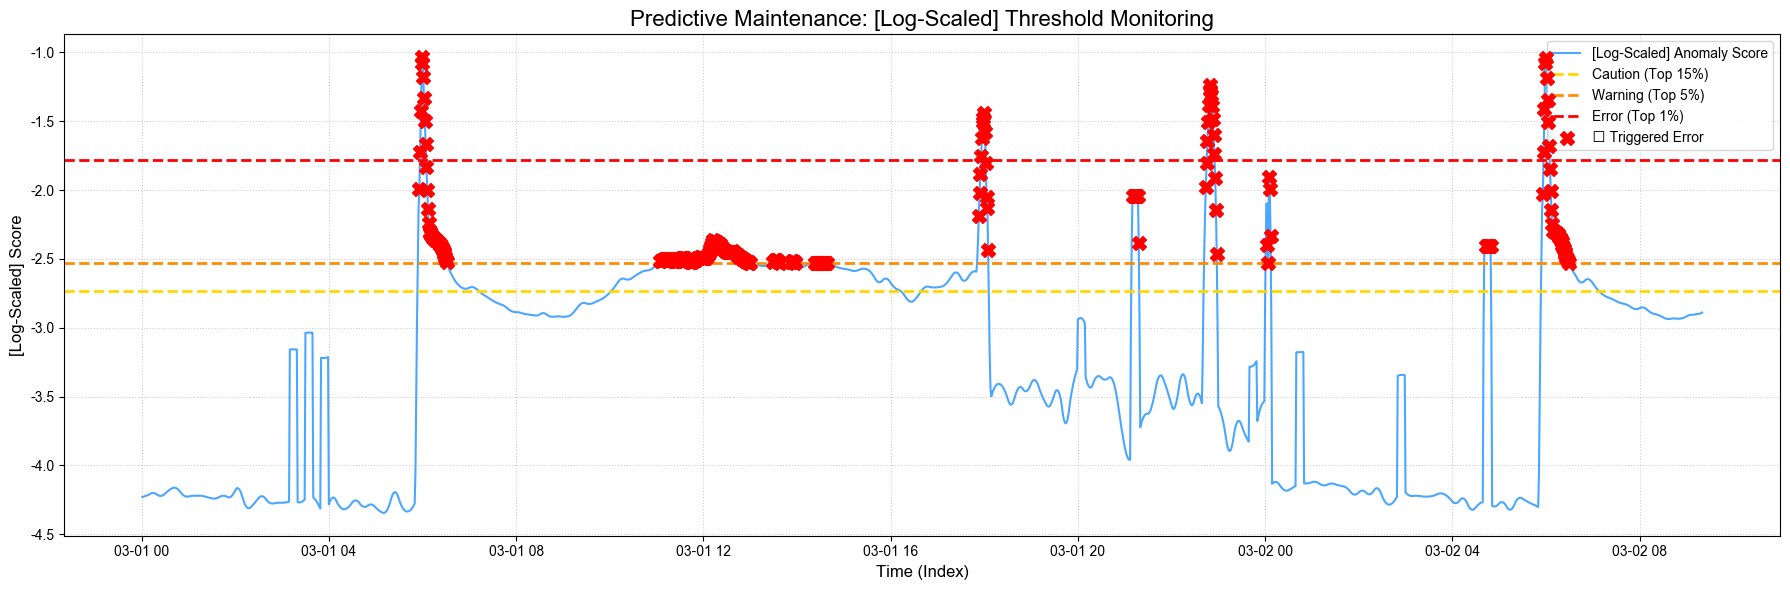

👀 [일반 버전] 그래프 출력


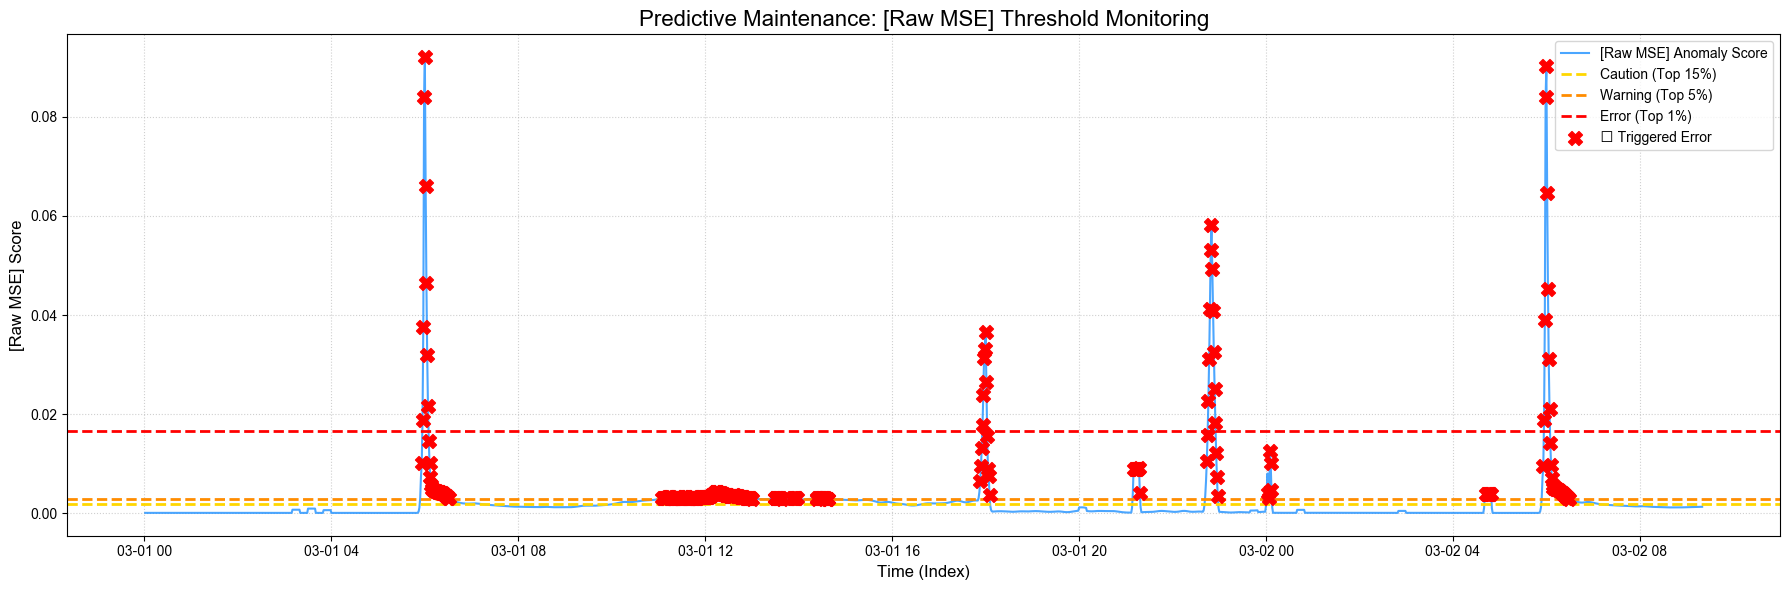

In [207]:
def plot_threshold_monitoring(df, start_idx=0, end_idx=2000):
    """
    시간의 흐름에 따른 AutoEncoder 오차(MSE)와 3단계 Threshold 초과 여부를 시각화합니다.
    """
    # 확대해서 볼 구간 설정
    df_subset = df.iloc[start_idx:end_idx]
    
    plt.figure(figsize=(20, 10))
    
    # 1. 오토인코더 오차(MSE) 흐름 (파란 선)
    plt.plot(df_subset.index, df_subset['ae_mse_score'], color='dodgerblue', alpha=0.8, label='MSE (Anomaly Score)')
    
    # 2. 3단계 Threshold 수평선 긋기 (이전 셀에서 정의한 thresh 변수들 사용)
    plt.axhline(thresh_caution, color='gold', linestyle='--', linewidth=2, label='Caution Threshold')
    plt.axhline(thresh_warning, color='darkorange', linestyle='--', linewidth=2, label='Warning Threshold')
    plt.axhline(thresh_error, color='red', linestyle='--', linewidth=2, label='Error Threshold')
    
    # 3. 디바운싱(연속 발생) 로직이 적용된 최종 알람 지점 찍기
    # Caution(1) 이상인 구간
    cautions = df_subset[df_subset['final_alarm_level'] == 1]
    plt.scatter(cautions.index, cautions['ae_mse_score'], color='gold', s=50, zorder=5)
    
    # Warning(2) 구간
    warnings = df_subset[df_subset['final_alarm_level'] == 2]
    plt.scatter(warnings.index, warnings['ae_mse_score'], color='darkorange', s=70, zorder=5)
    
    # Error(3) 구간 (가장 중요하므로 크고 눈에 띄게)
    errors = df_subset[df_subset['final_alarm_level'] == 3]
    plt.scatter(errors.index, errors['ae_mse_score'], color='red', s=100, marker='X', zorder=6, label='Triggered Error 🚨')
    
    plt.title('Predictive Maintenance: Anomaly Score & Threshold Monitoring', fontsize=16, fontweight='bold')
    plt.xlabel('Time (Index / Timestamp)', fontsize=12)
    plt.ylabel('Reconstruction Error (MSE)', fontsize=12)
    plt.legend(loc='upper right')
    

# ==============================================================================
# 📊 [Part 1] 데이콘 스타일: 다이내믹 Threshold 시각화 함수
# ==============================================================================
def plot_threshold_monitoring(df, score_type='log', start_idx=0, end_idx=2000):
    """
    score_type: 'normal' (일반 MSE) 또는 'log' (Log MSE) 선택 가능
    """
    df_subset = df.iloc[start_idx:end_idx].copy()
    
    # 옵션에 따라 사용할 컬럼과 이름 결정
    if score_type == 'log':
        target_col = 'ae_log_mse_score'
        title_prefix = '[Log-Scaled]'
    else:
        target_col = 'ae_mse_score'
        title_prefix = '[Raw MSE]'
        
    # 해당 스코어 기준의 임계값 다시 계산 (동적 할당)
    t_caut = np.percentile(df[target_col].dropna(), 85)
    t_warn = np.percentile(df[target_col].dropna(), 95)
    t_err  = np.percentile(df[target_col].dropna(), 99)
    
    plt.figure(figsize=(18, 6))
    
    # 1. 스코어 흐름 (파란 선)
    plt.plot(df_subset.index, df_subset[target_col], color='dodgerblue', alpha=0.8, label=f'{title_prefix} Anomaly Score')
    
    # 2. 3단계 Threshold
    plt.axhline(t_caut, color='gold', linestyle='--', linewidth=2, label='Caution (Top 15%)')
    plt.axhline(t_warn, color='darkorange', linestyle='--', linewidth=2, label='Warning (Top 5%)')
    plt.axhline(t_err, color='red', linestyle='--', linewidth=2, label='Error (Top 1%)')
    
    # 3. 에러 발생 지점 마킹 (final_alarm_level 기준)
    errors = df_subset[df_subset['final_alarm_level'] == 3]
    if not errors.empty:
        plt.scatter(errors.index, errors[target_col], color='red', s=100, marker='X', zorder=6, label='🚨 Triggered Error')
    
    plt.title(f'Predictive Maintenance: {title_prefix} Threshold Monitoring', fontsize=16, fontweight='bold')
    plt.xlabel('Time (Index)', fontsize=12)
    plt.ylabel(f'{title_prefix} Score', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 실행 테스트 (옵션만 바꾸면 두 가지 다 볼 수 있습니다!)
df_interpret_final['ae_log_mse_score'] = np.log10(df_interpret_final['ae_mse_score'] + 1e-10)

print("👀 [로그 버전] 그래프 출력")
plot_threshold_monitoring(df_interpret_final, score_type='log', start_idx=0, end_idx=2000)

print("👀 [일반 버전] 그래프 출력")
plot_threshold_monitoring(df_interpret_final, score_type='normal', start_idx=0, end_idx=2000)

In [208]:
# ==============================================================================
# 🚨 [Part 2] 현업 관제용: 고장 진단 리포트 (Root Cause Analysis) 생성기
# ==============================================================================
# 변경점: 시간(Timestamp)과 정수 위치(iloc)를 둘 다 받도록 파라미터 수정
def generate_anomaly_diagnostic_report(target_timestamp, target_iloc, X_scaled_data, feature_names, threshold_val, model):
    """
    특정 시점의 데이터를 받아, 왜 에러가 났는지 Top 3 원인을 뽑아주는 함수
    """
    
    # 1. 넘파이 배열은 반드시 정수(target_iloc)로 접근해야 합니다!
    x_input = X_scaled_data[target_iloc].reshape(1, -1)
    
    # 2. 모델에 넣고 예측(복원) 해보기
    x_pred = model.predict(x_input, verbose=0)
    
    # 3. 전체 MSE 및 피처별 오차(Squared Error) 계산
    total_mse = np.mean(np.power(x_input - x_pred, 2))
    feature_errors = np.power(x_input - x_pred, 2)[0] # 1차원 배열로 펼치기
    
    # 4. 리포트 출력 포맷팅
    print("\n" + "🔥"*30)
    print(f" 🚨 [이상 진단 리포트] 발생 시점: {target_timestamp}")
    print("🔥"*30)
    
    print(f"▶ 판정 결과: {'[위험/Error]' if total_mse > threshold_val else '[정상/Normal]'}")
    print(f"▶ 현재 Score (MSE) : {total_mse:.6f}")
    print(f"▶ 위험 Threshold   : {threshold_val:.6f}")
    print("-" * 50)
    
    if total_mse > threshold_val:
        print("💡 [Root Cause Analysis] 오차 발생 원인 센서 Top 3")
        
        # 피처별 오차를 데이터프레임으로 만들어 내림차순 정렬
        df_errors = pd.DataFrame({
            'Feature': feature_names,
            'Error_Contribution': feature_errors
        }).sort_values(by='Error_Contribution', ascending=False)
        
        # 전체 오차 대비 기여도(%) 계산
        sum_error = df_errors['Error_Contribution'].sum()
        df_errors['Contribution_Pct'] = (df_errors['Error_Contribution'] / sum_error) * 100
        
        # Top 3 출력
        for i, (idx, row) in enumerate(df_errors.head(3).iterrows(), 1):
            print(f"  {i}위: {row['Feature']:<30} (기여도: {row['Contribution_Pct']:.1f}%)")
            
        print("\n📝 [조치 권고]")
        top1_feature = df_errors.iloc[0]['Feature']
        print(f"  -> 가장 기여도가 높은 [{top1_feature}] 센서 및 관련 설비의 즉각적인 점검이 필요합니다.")
    print("=" * 60)

# ==============================================================================
# 🎯 [실행] 에러가 발생한 시점을 하나 골라서 진단 리포트 뽑아보기   
# ==============================================================================
# 'Error(3)' 레벨이 뜬 인덱스 번호들만 추출
error_indices = df_interpret_final[df_interpret_final['final_alarm_level'] == 3].index

if len(error_indices) > 0:
    # 🌟 에러가 발생한 첫 번째 시간(Timestamp 라벨)
    target_time = error_indices[0] 
    
    # 🌟 핵심: 넘파이에 넣기 위해 해당 시간이 전체 데이터 중 몇 번째 줄인지(정수형 위치) 찾기
    target_int_loc = df_interpret_final.index.get_loc(target_time)
    
    # 이전에 설정한 가장 빡센 99% Threshold (일반 MSE 기준)
    err_threshold = np.percentile(mse_scores, 99) 
    
    # 우리가 처음에 X_train_ae 만들 때 썼던 피처 리스트(robust_features) 
    feature_list = X_train_ae.columns.tolist()
    
    # 리포트 생성기 가동! 
    generate_anomaly_diagnostic_report(
        target_timestamp=target_time,   # 출력용 라벨
        target_iloc=target_int_loc,     # 데이터 추출용 정수 위치
        X_scaled_data=X_scaled,     
        feature_names=feature_list, 
        threshold_val=err_threshold, 
        model=autoencoder           
    )
else:
    print("현재 구간에는 Error 레벨에 도달한 알람이 없습니다. 평화롭네요! 🕊️")


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
 🚨 [이상 진단 리포트] 발생 시점: 2026-03-01 05:56:00
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
▶ 판정 결과: [정상/Normal]
▶ 현재 Score (MSE) : 0.010138
▶ 위험 Threshold   : 0.016522
--------------------------------------------------


👀 오차(MSE) 스코어가 Threshold를 넘어가는 순간 확인하기


/var/folders/29/5wmqbm4j3x10qv5vgm_bm8f80000gn/T/ipykernel_27485/3001324870.py:79: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()


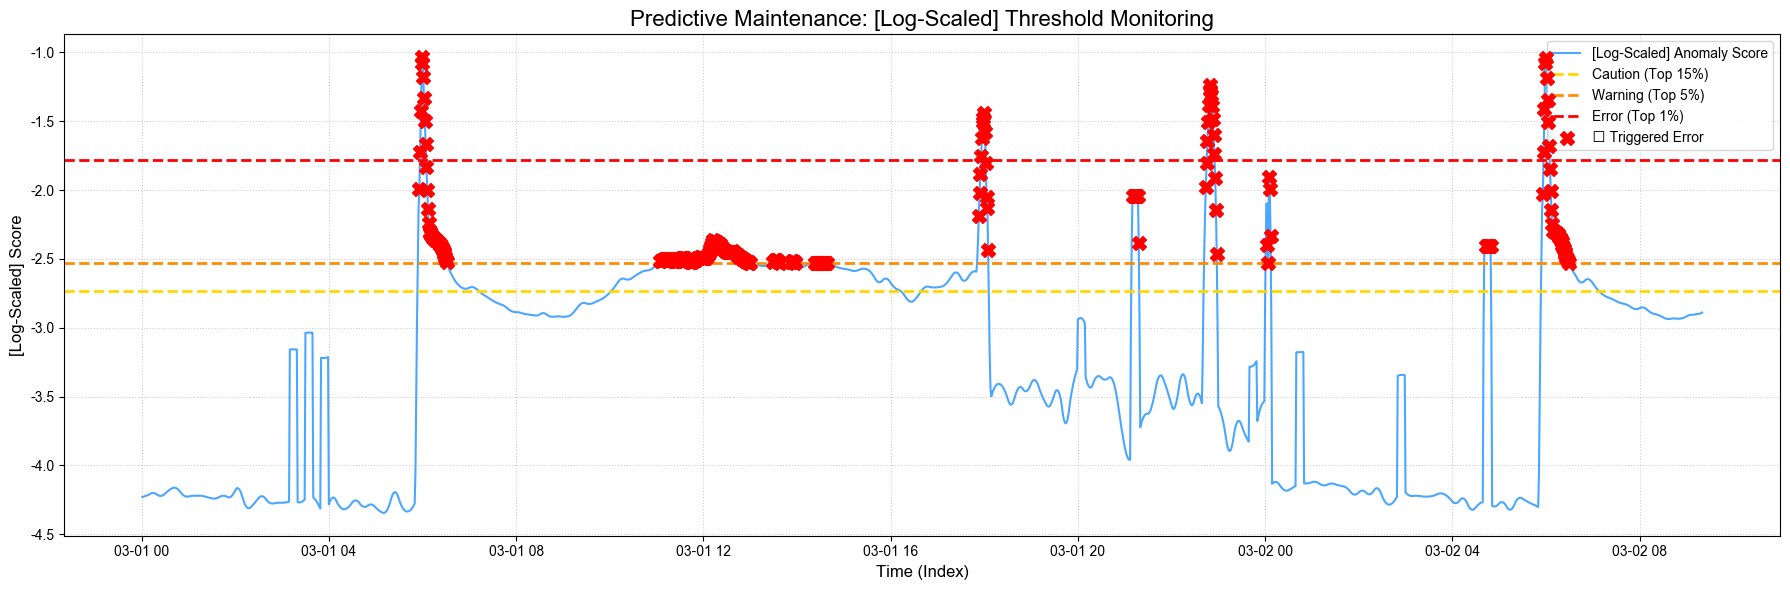

In [209]:
# ==============================================================================
# 🚀 그래프 그려보기
# ==============================================================================
print("👀 오차(MSE) 스코어가 Threshold를 넘어가는 순간 확인하기")

# 처음 2000개 데이터 구간 확인 (값이 비정상적으로 튀는 구간이 있다면 인덱스를 조절해보세요!)
plot_threshold_monitoring(df_interpret_final, start_idx=0, end_idx=2000)

# 만약 이상(Error)이 발생한 정확한 시점을 찾아서 그 주변을 확대해보고 싶다면?
# error_indices = df_interpret_final[df_interpret_final['final_alarm_level'] == 3].index
# if len(error_indices) > 0:
#     first_error = error_indices[0]
#     # 첫 번째 에러 발생 시점 앞뒤로 500개씩만 짤라서 자세히 보기
#     plot_threshold_monitoring(df_interpret_final, start_idx=max(0, first_error-500), end_idx=first_error+500)

# 테스트

In [210]:
from IPython.display import display

print("🚨 [Phase 7] 전체 알람 로그 수집 및 자동 RCA(Root Cause Analysis) 진행...")

# -------------------------------------------------------------------------
# 1. 3단계 알람(노랑, 주황, 빨강) 발생 횟수 전체 집계
# -------------------------------------------------------------------------
cautions = df_interpret_final[df_interpret_final['final_alarm_level'] == 1]
warnings = df_interpret_final[df_interpret_final['final_alarm_level'] == 2]
errors   = df_interpret_final[df_interpret_final['final_alarm_level'] == 3]

print("-" * 50)
print(f"🔸 주의 (Caution) 구간: {len(cautions)} 건")
print(f"🟠 경고 (Warning) 구간: {len(warnings)} 건")
print(f"🔴 위험 (Error)   구간: {len(errors)} 건")
print("-" * 50)

# -------------------------------------------------------------------------
# 2. 빨간색(Error) 구간에 대한 자동 원인 분석 및 저장 로직
# -------------------------------------------------------------------------
rca_reports = [] # 분석 결과를 담을 빈 바구니

if len(errors) > 0:
    print(f"\n🔍 총 {len(errors)}개의 Error(위험) 구간에 대해 딥러닝 원인 분석(RCA)을 시작합니다...")
    
    # 모델에 넣을 피처 이름 리스트
    feature_list = X_train_ae.columns.tolist()
    
    # 빨간 점이 찍힌 모든 시간(인덱스)에 대해 루프를 돕니다.
    for target_time in errors.index:
        # 1) 해당 시간의 정수형 위치(iloc) 찾기
        target_int_loc = df_interpret_final.index.get_loc(target_time)
        
        # 2) 텐서플로우 모델로 예측(복원) 수행
        x_input = X_scaled[target_int_loc].reshape(1, -1)
        x_pred = autoencoder.predict(x_input, verbose=0)
        
        # 3) 전체 오차 및 피처별 기여도 계산
        total_mse = np.mean(np.power(x_input - x_pred, 2))
        feature_errors = np.power(x_input - x_pred, 2)[0]
        
        # 4) 오차가 큰 순서대로 정렬
        df_err_calc = pd.DataFrame({
            'Feature': feature_list,
            'Error_Contribution': feature_errors
        }).sort_values(by='Error_Contribution', ascending=False)
        
        sum_error = df_err_calc['Error_Contribution'].sum()
        df_err_calc['Contribution_Pct'] = (df_err_calc['Error_Contribution'] / sum_error) * 100
        
        # 5) Top 1, 2, 3위 정보 추출
        top1 = df_err_calc.iloc[0]
        top2 = df_err_calc.iloc[1]
        top3 = df_err_calc.iloc[2]
        
        # 6) 결과 바구니에 차곡차곡 담기
        rca_reports.append({
            'Occurred_Time': target_time,
            'Total_MSE_Score': round(total_mse, 6),
            'Top1_Root_Cause': top1['Feature'],
            'Top1_Contribution(%)': round(top1['Contribution_Pct'], 1),
            'Top2_Root_Cause': top2['Feature'],
            'Top2_Contribution(%)': round(top2['Contribution_Pct'], 1),
            'Top3_Root_Cause': top3['Feature'],
            'Top3_Contribution(%)': round(top3['Contribution_Pct'], 1),
            'Action_Required': f"Inspect {top1['Feature']}" # 조치 권고안 자동 생성
        })
        
    # -------------------------------------------------------------------------
    # 3. 분석 결과를 Pandas DataFrame으로 변환 후 CSV로 영구 저장!
    # -------------------------------------------------------------------------
    df_rca_log = pd.DataFrame(rca_reports)
    
    # CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 사용)
    csv_filename = "../data/Anomaly_RCA_Diagnostic_Log.csv"
    df_rca_log.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    
    print(f"\n✅ 완벽합니다! 모든 에러의 원인 분석이 끝났습니다.")
    print(f"📁 결과가 [{csv_filename}] 파일로 저장되었습니다.")
    print("\n[저장된 RCA 리포트 미리보기 (상위 5개)]")
    display(df_rca_log.head()) # 주피터 노트북에 표 형태로 예쁘게 출력
    
else:
    print("\n현재 구간에는 Error 레벨에 도달한 알람이 없으므로 분석을 건너뜁니다.")

🚨 [Phase 7] 전체 알람 로그 수집 및 자동 RCA(Root Cause Analysis) 진행...
--------------------------------------------------
🔸 주의 (Caution) 구간: 598 건
🟠 경고 (Warning) 구간: 13293 건
🔴 위험 (Error)   구간: 5548 건
--------------------------------------------------

🔍 총 5548개의 Error(위험) 구간에 대해 딥러닝 원인 분석(RCA)을 시작합니다...

✅ 완벽합니다! 모든 에러의 원인 분석이 끝났습니다.
📁 결과가 [../data/Anomaly_RCA_Diagnostic_Log.csv] 파일로 저장되었습니다.

[저장된 RCA 리포트 미리보기 (상위 5개)]


,Occurred_Time,Total_MSE_Score,Top1_Root_Cause,Top1_Contribution(%),Top2_Root_Cause,Top2_Contribution(%),Top3_Root_Cause,Top3_Contribution(%),Action_Required
0,2026-03-01 05:56:00,0.010138,raw_tank_level_pct,70.5,pump_rpm,23.5,filter_pressure_in_kpa,4.5,Inspect raw_tank_level_pct
1,2026-03-01 05:57:00,0.018759,raw_tank_level_pct,53.8,differential_pressure_kpa,28.2,filter_pressure_in_kpa,11.7,Inspect raw_tank_level_pct
2,2026-03-01 05:58:00,0.037673,differential_pressure_kpa,36.0,raw_tank_level_pct,30.7,filter_pressure_in_kpa,25.1,Inspect differential_pressure_kpa
3,2026-03-01 05:59:00,0.083976,differential_pressure_kpa,31.5,filter_pressure_in_kpa,29.4,pump_rpm,20.7,Inspect differential_pressure_kpa
4,2026-03-01 06:00:00,0.092036,differential_pressure_kpa,29.9,filter_pressure_in_kpa,29.8,pump_rpm,19.8,Inspect differential_pressure_kpa


In [211]:
import joblib, json

threshold_99 = np.percentile(mse_scores, 99)

print("\n💾 3. 서버 배포용 아티팩트(Artifacts) 저장...")
# (1) 모델 저장
autoencoder.save("../models/model.keras")

# (2) 스케일러 저장
joblib.dump(scaler, "../models/scaler.pkl")

# (3) 설정(Config) 저장: 임계값과 피처 순서
config = {"threshold": float(threshold_99), "features": X_train_ae.columns.tolist()}
with open("../models/model_config.json", "w") as f:
    json.dump(config, f)

print("✅ 학습 및 저장 완료! (model.keras, scaler.pkl, model_config.json 생성됨)")



💾 3. 서버 배포용 아티팩트(Artifacts) 저장...
✅ 학습 및 저장 완료! (model.keras, scaler.pkl, model_config.json 생성됨)
